⚠️ Execution note

This notebook shows the original exploratory work. Paths no longer match because the project was later refactored into Python scripts. The logic is correct, but the notebook will not run without updating the paths. It is kept only for documentation/versioning purposes.

In [1]:
import pandas as pd
import random
import pickle
import numpy as np
import math
import matplotlib.pyplot as plt
import os

from collections import defaultdict

In [2]:
load_path = "../../data/2_preprocessed/pcy/pcy_pass2_frequent_pairs.pkl"

with open(load_path, "rb") as f:
    data = pickle.load(f)

frequent_pairs = data["frequent_pairs"]
item_counts = data["item_counts"]
num_buckets = data["num_buckets"]
support_threshold = data["support_threshold"]

print("Loaded frequent pairs:", len(frequent_pairs))


Loaded frequent pairs: 74


<h3> <span style="color:green; font-weight:bold; background-color: #f0f0f0; padding: 6px; border-radius: 4px;">
Checking Loaded PCY Results </span> </h3>

This step simply verifies that the data stored from PCY Pass 2 has been loaded correctly.  
It confirms that the frequent pairs, item counts, and configuration values match the original computation before continuing with the analysis.

In [3]:
# Sort by frequency descending
sorted_pairs = sorted(frequent_pairs.items(), key=lambda x: x[1], reverse=True)

print("Top 10 frequent pairs after loading pickle:\n")
for i, ((a, b), count) in enumerate(sorted_pairs[:10]):
    print(f"{i+1}. ({a}, {b}) → {count}")

Top 10 frequent pairs after loading pickle:

1. (13176, 47209) → 57344
2. (13176, 21137) → 55839
3. (21137, 24852) → 51921
4. (24852, 47766) → 48892
5. (21903, 24852) → 47088
6. (13176, 21903) → 45611
7. (21137, 47209) → 37818
8. (16797, 24852) → 37185
9. (13176, 27966) → 36894
10. (24852, 47626) → 36550


<h3><span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Merging Orders with Product Data
</span></h3>

This step combines the `orders` and `order_products__prior` tables in order to attach  
a `user_id` to every purchased `product_id`.  
The result allows identifying which user bought which products across all orders.

In [4]:
orders = pd.read_parquet("../../data/1_cleaned/orders.pq")
order_products = pd.read_parquet("../../data/1_cleaned/order_products__prior.pq")

# Merge to attach user_id to each product_id
merged = order_products.merge(orders[["order_id", "user_id"]], on="order_id")

# Build user → set of purchased products
user_baskets = merged.groupby("user_id")["product_id"].apply(set).to_dict()

<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Loading Product Metadata
</span></h3>

The product catalog is loaded and a mapping from `product_id` to `product_name` is created.  
This mapping enables converting frequent item pairs from numeric IDs into readable product names.

In [5]:
# Load products and create mapping product_id -> product_name
products_df = pd.read_parquet("../../data/1_cleaned/products.pq")
id_to_name = dict(zip(products_df["product_id"], products_df["product_name"]))

<span style="display:inline-block; background-color:#f0f0f0; padding:6px 10px; border-radius:4px; font-size:22px; font-weight:bold;">
  <span style="color:red;">Reconstructing</span>
  <span style="color:green;">Transaction Baskets</span>
</span>


Each order is transformed into a list of purchased product IDs,  
creating the complete set of customer baskets.  
This dataset is required to compute support, confidence, and lift  
for the association rules derived from the PCY frequent pairs.


In [6]:
# Rebuild baskets from order_products (one basket per order_id)
baskets_series = order_products.groupby("order_id")["product_id"].apply(list)
baskets = baskets_series.tolist()

N = len(baskets)  # total number of baskets
print("Number of baskets:", N)

Number of baskets: 3214874


<span style="display:inline-block; background-color:#f0f0f0; padding:6px 10px; border-radius:4px; font-size:22px; font-weight:bold;">
    <span style="color:red;">Rebuilding</span>
    <span style="color:green;">Association Rules from Frequent Pairs</span>
</span>
 

Using the saved PCY frequent pairs and the reconstructed baskets,  
support, confidence, and lift are recalculated for every item pair.  
The resulting rules are stored in `df_rules` and sorted by lift,  
preparing the dataset for personalized product recommendations.


In [7]:
# Rebuild df_rules from frequent_pairs and item_counts

rules = []
N = len(baskets)   # total number of baskets

for (a, b), pair_cnt in frequent_pairs.items():

    # support(pair)
    support_ab = pair_cnt / N

    # support(A), support(B)
    support_a = item_counts[a] / N
    support_b = item_counts[b] / N

    # confidence
    conf_a_b = support_ab / support_a
    conf_b_a = support_ab / support_b

    # lift
    lift_ab = support_ab / (support_a * support_b)

    rules.append({
        "A": id_to_name[a],
        "B": id_to_name[b],
        "support": support_ab,
        "confidence_A_to_B": conf_a_b,
        "confidence_B_to_A": conf_b_a,
        "lift": lift_ab
    })

# Convert to dataframe
df_rules = pd.DataFrame(rules)

# Sort by lift descending
df_rules = df_rules.sort_values(by="lift", ascending=False).reset_index(drop=True)

print("df_rules created successfully!")
df_rules.head()


df_rules created successfully!


,A,B,support,confidence_A_to_B,confidence_B_to_A,lift
0,Limes,Organic Cilantro,0.004870,0.122149,0.251050,6.297018
1,Organic Yellow Onion,Organic Garlic,0.006318,0.195082,0.201260,6.214540
2,Limes,Large Lemon,0.007577,0.190051,0.178708,4.482483
3,Organic Lemon,Organic Hass Avocado,0.006100,0.244073,0.099146,3.966756
4,Organic Cucumber,Organic Hass Avocado,0.004957,0.220002,0.080557,3.575554


<span style="display:inline-block; background-color:#f0f0f0; padding:6px 10px; border-radius:4px; font-size:22px; font-weight:bold;">
  <span style="color:blue;">Personalized Recommendation System</span>
</span>

<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Load & Prepare User Baskets (PRIOR/TRAIN) + Recency Field
</span></h3>

- Loads Instacart CSVs and builds `product_id → product_name`.  
- Merges `orders` to attach `user_id` & `order_number` (needed for repeat/recency).  
- Creates per-user baskets:
  - `user_baskets` from PRIOR (history for rules),
  - `future_baskets` from TRAIN (for evaluation).  
- Computes `users_with_future` and prints quick sanity counts.  
- Includes light schema checks to fail fast if required columns are missing.


In [8]:
# Core datasets
df_train  = pd.read_parquet("../../data/1_cleaned/order_products__train.pq")
df_prior  = pd.read_parquet("../../data/1_cleaned/order_products__prior.pq")
orders    = pd.read_parquet("../../data/1_cleaned/orders.pq")
products  = pd.read_parquet("../../data/1_cleaned/products.pq")

# Schema guards (fail fast)
required_orders_cols = {"order_id", "user_id", "order_number"}
required_prior_cols  = {"order_id", "product_id"}
required_train_cols  = {"order_id", "product_id"}
required_prod_cols   = {"product_id", "product_name"}

assert required_orders_cols.issubset(orders.columns),   "orders missing required columns"
assert required_prior_cols.issubset(df_prior.columns),  "prior missing required columns"
assert required_train_cols.issubset(df_train.columns),  "train missing required columns"
assert required_prod_cols.issubset(products.columns),   "products missing required columns"

# product_id → product_name
id_to_name = dict(zip(products["product_id"], products["product_name"]))

# Keep only what's needed; order_number is used for recency in repeat scoring
orders_small = orders[["order_id", "user_id", "order_number"]]

# Attach user_id (+ order_number) to lines in PRIOR and TRAIN
prior_merged = df_prior.merge(orders_small, on="order_id", how="inner")
train_merged = df_train.merge(orders_small, on="order_id", how="inner")

# PRIOR baskets = training history for rules
user_baskets = prior_merged.groupby("user_id")["product_id"].apply(set).to_dict()

# TRAIN baskets = future purchases for evaluation
future_baskets = train_merged.groupby("user_id")["product_id"].apply(set).to_dict()

# Users with both past and future
users_with_future = set(user_baskets.keys()) & set(future_baskets.keys())

print("Users with history (PRIOR):", len(user_baskets))
print("Users with future (TRAIN):", len(future_baskets))
print("Users with both:", len(users_with_future))
print("Example users:", list(users_with_future)[:10])


Users with history (PRIOR): 206209
Users with future (TRAIN): 206209
Users with both: 206209
Example users: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Deduplicate (A,B) Rules + Rebuild rule_map (AGG_MODE with Confidence Tie-Break)
</span></h3>

- Guarantees **one row per (A,B)** in `df_rules` before building `rule_map`.
- `AGG_MODE`: `"max"` (default, tie-break by higher `confidence_A_to_B"`), `"mean"`, or `"median"`.
- Prints removal stats (rows/pairs) for audit; asserts no duplicates remain.
- Rebuilds `rule_map[A] → [(B, lift)]` sorted by lift (desc).

In [9]:
# Requires: import numpy as np, import pandas as pd
AGG_MODE = "max"  # options: "max", "mean", "median"

assert {"A","B","lift"}.issubset(df_rules.columns), "df_rules must include columns: A,B,lift"

before_rows  = len(df_rules)
before_pairs = df_rules[["A","B"]].drop_duplicates().shape[0]

def _dedup_max_with_tiebreak(df: pd.DataFrame) -> pd.DataFrame:
    # Secondary key: confidence_A_to_B if present (why: prefer stronger/confident rules)
    sort_cols = ["A", "B", "lift"]
    ascending = [True, True, False]
    if "confidence_A_to_B" in df.columns:
        sort_cols.append("confidence_A_to_B")
        ascending.append(False)
    return (
        df.sort_values(sort_cols, ascending=ascending)
            .drop_duplicates(subset=["A","B"], keep="first")
            .reset_index(drop=True)
    )

if AGG_MODE == "max":
    df_rules_dedup = _dedup_max_with_tiebreak(df_rules)
elif AGG_MODE in {"mean", "median"}:
    _agg_fn = (np.mean if AGG_MODE == "mean" else np.median)
    num_cols = [c for c in ["support","confidence_A_to_B","confidence_B_to_A","lift"] if c in df_rules.columns]
    agg_spec = {c: _agg_fn for c in num_cols}
    df_rules_dedup = (
        df_rules.groupby(["A","B"], as_index=False)
                .agg(agg_spec)
                .sort_values("lift", ascending=False)
                .reset_index(drop=True)
    )
else:
    raise ValueError("Invalid AGG_MODE. Use one of: 'max', 'mean', 'median'.")

after_rows  = len(df_rules_dedup)
after_pairs = df_rules_dedup[["A","B"]].drop_duplicates().shape[0]
removed_rows  = before_rows  - after_rows
removed_pairs = before_pairs - after_pairs
pct_rows = (removed_rows / before_rows * 100) if before_rows else 0.0

print("=== Rules Dedup Summary (AGG_MODE:", AGG_MODE, ") ===")
print(f"Rows: before={before_rows}  after={after_rows}  removed={removed_rows} ({pct_rows:.2f}%)")
print(f"(A,B) pairs: before={before_pairs}  after={after_pairs}  removed_pairs={removed_pairs}")

# Build rule_map from deduped rules
rule_map = {}
for _, row in df_rules_dedup.iterrows():
    A, B, lift = row["A"], row["B"], float(row["lift"])
    rule_map.setdefault(A, []).append((B, lift))

for A in rule_map:
    rule_map[A].sort(key=lambda x: x[1], reverse=True)

# Safety guard
assert df_rules_dedup.duplicated(subset=["A","B"]).sum() == 0, "Duplicate (A,B) remain after dedup"

=== Rules Dedup Summary (AGG_MODE: max ) ===
Rows: before=74  after=74  removed=0 (0.00%)
(A,B) pairs: before=74  after=74  removed_pairs=0


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Lift-Based NOVEL Recommender (Top-K, Excludes Previously Bought)
</span></h3>

- Aggregates **lift** from rules `A→B` over the user’s purchased items `A`.  
- Excludes items already bought (**novel** only).  
- Deterministic ranking (tie-break by item name).  
- **Inputs:** `user_baskets`, `id_to_name`, `rule_map`. **Output:** list of `(item_name, score)`.


In [10]:
def recommend_for_user(user_id: int, top_k: int = 5):
    """Lift-aggregated NOVEL recommendations (skip already purchased)."""
    if user_id not in user_baskets:
        return []

    purchased_ids = user_baskets[user_id]
    purchased_names = {id_to_name[i] for i in purchased_ids if i in id_to_name}

    candidates: dict[str, float] = {}
    for A in purchased_names:
        if A not in rule_map:
            continue
        for B, lift_score in rule_map[A]:
            if B in purchased_names:
                continue
            candidates[B] = candidates.get(B, 0.0) + float(lift_score)

    # Stable deterministic order: score desc, then name asc
    ranked = sorted(candidates.items(), key=lambda x: (-x[1], x[0]))[:top_k]
    return ranked  # list[(item_name, score)]

<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Rule-Based Recommender (precomputed confidence map, deterministic ranking)
</span></h3>

- Precomputes a global **`CONF_MAP[(A,B)] → confidence_A_to_B`** from `df_rules_dedup` (one-time) for faster lookups.
- `recommend_with_explanations(user_id, top_k, allow_repeat)`:
  - Aggregates **lift** over rules `A→B` from the user’s purchased `A`.
  - Controls repeats via `allow_repeat` (`False` = NOVEL-only).
  - Builds compact **explanations** per item (lift + confidence if available).
  - Deterministic sort: **score desc**, then **item name asc**.
- **Inputs:** `rule_map`, `df_rules_dedup`, `user_baskets`, `id_to_name`. **Output:** `[{recommended_item, score, explanations}]`.


In [11]:
# After df_rules_dedup exists (one-time)
if {"A","B","confidence_A_to_B"}.issubset(df_rules_dedup.columns):
    CONF_MAP = {
        (row["A"], row["B"]): float(row["confidence_A_to_B"])
        for _, row in df_rules_dedup.iterrows()
        if pd.notna(row.get("confidence_A_to_B", None))
    }
else:
    CONF_MAP = {}

def recommend_with_explanations(user_id: int, top_k: int = 5, allow_repeat: bool = False):
    if user_id not in user_baskets:
        return []
    purchased_names = {id_to_name[i] for i in user_baskets[user_id] if i in id_to_name}
    explanations, scores = {}, {}
    for A in purchased_names:
        for B, lift_score in rule_map.get(A, []):
            if (not allow_repeat) and (B in purchased_names):
                continue
            explanations.setdefault(B, [])
            scores[B] = scores.get(B, 0.0) + float(lift_score)
            conf = CONF_MAP.get((A, B))
            msg = (f"because you bought '{A}' (lift={float(lift_score):.2f}"
                   + (f", confidence={conf:.2f})" if conf is not None else ")"))
            explanations[B].append(msg)
    ranked = sorted(scores.items(), key=lambda x: (-x[1], x[0]))[:top_k]
    return [{"recommended_item": it, "score": sc, "explanations": explanations[it]} for it, sc in ranked]


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Repeat Stats with Min-Freq Filter + Per-User Normalized Recency (safe dtypes & fallback)
</span></h3>

- Computes per `(user_id, product_id)` **freq** and **last_order_number** from PRIOR.
- Filters by `MIN_FREQ` (default 2). Keeps an **unfiltered copy** for potential fallbacks.
- Adds **`norm_last_onum`** ∈ [0,1] per user (0=oldest, 1=newest). Safe when user has one order.
- Cleans dtypes (numeric) and drops corrupted rows.
- Prints kept ratio; warns if the filter empties the table.


In [12]:
# Config
MIN_FREQ = 2  # keep only user-item pairs seen at least this many times

# Guards
assert {"user_id", "product_id", "order_number"}.issubset(prior_merged.columns), \
    "prior_merged must have user_id, product_id, order_number"

# Aggregates
group = prior_merged.groupby(["user_id", "product_id"], sort=False)
user_item_freq = group.size().rename("freq").reset_index()
user_item_last_onum = group["order_number"].max().rename("last_order_number").reset_index()

# Merge
user_item_stats = user_item_freq.merge(user_item_last_onum, on=["user_id", "product_id"], how="inner")

# Dtypes → numeric; drop bad rows if any
for c in ["user_id", "product_id", "freq", "last_order_number"]:
    user_item_stats[c] = pd.to_numeric(user_item_stats[c], errors="coerce")
user_item_stats = user_item_stats.dropna(subset=["user_id", "product_id", "freq", "last_order_number"]).copy()

# Keep an unfiltered copy (optional fallback for very light users)
user_item_stats_full = user_item_stats.copy()

# Filter by min frequency
before_rows = len(user_item_stats)
user_item_stats = user_item_stats[user_item_stats["freq"] >= MIN_FREQ].copy()
after_rows = len(user_item_stats)

# Per-user min–max normalization of recency
# norm_last_onum = 0 for a user's oldest, 1 for newest (safe when max==min)
if not user_item_stats.empty:
    u_min = user_item_stats.groupby("user_id")["last_order_number"].transform("min")
    u_max = user_item_stats.groupby("user_id")["last_order_number"].transform("max")
    den = (u_max - u_min).replace(0, 1)  # avoid div-by-zero
    user_item_stats["norm_last_onum"] = (user_item_stats["last_order_number"] - u_min) / den
else:
    user_item_stats["norm_last_onum"] = pd.Series(dtype=float)

kept_pct = (after_rows / max(before_rows, 1)) * 100.0
print(f"[Repeat stats] rows before={before_rows} after_freq≥{MIN_FREQ}={after_rows}; kept={kept_pct:.2f}%")
if after_rows == 0:
    print("[WARN] All rows filtered by MIN_FREQ. Consider using fallback or lowering MIN_FREQ.")


[Repeat stats] rows before=13307953 after_freq≥2=5325258; kept=40.02%


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Repeat & Hybrid Recommenders (Freq + Normalized Recency) and Rule Blend
</span></h3>

- **Repeat:** `score_repeat = freq + λ·norm_last_onum` (uses per-user normalized recency; fallback to freq≥1 if needed).  
- **Hybrid:** Min–max normalizes NOVEL/REPEAT scores and blends: `final = α·novel + (1−α)·repeat`.  
- Deterministic sort (score ↓, name ↑).  
- **Inputs:** `user_item_stats` (with `norm_last_onum`), `user_item_stats_full` (fallback), `user_baskets`, `id_to_name`, `recommend_with_explanations`.  
- **Tune:** `RECENCY_LAMBDA` (recency weight), `alpha` (novel vs repeat).

In [13]:
# Config: recency weight in repeat score
RECENCY_LAMBDA = 0.5  # increase to emphasize recency more

def _safe_name(pid: int) -> str:
    return id_to_name.get(pid, f"product_id={pid}")

def recommend_repeats(user_id: int, top_k: int = 6):
    """Repeat recommendations ranked by freq + RECENCY_LAMBDA*norm_last_onum, with per-user fallback."""
    if user_id not in user_baskets:
        return []

    # Primary: precomputed stats with MIN_FREQ filter & normalized recency
    subset = user_item_stats[user_item_stats["user_id"] == user_id]

    # Fallback: if MIN_FREQ filtered everything for this user, use unfiltered stats (freq>=1)
    if subset.empty:
        if "user_item_stats_full" in globals():
            subset = user_item_stats_full[user_item_stats_full["user_id"] == user_id].copy()
            if subset.empty:
                return []
            # Ensure normalized recency exists
            umin = subset["last_order_number"].min()
            umax = subset["last_order_number"].max()
            subset["norm_last_onum"] = 1.0 if umax == umin else (
                subset["last_order_number"] - umin
            ) / (umax - umin)
        else:
            return []

    tmp = subset.copy()
    # Composite repeat score
    tmp["score_repeat"] = tmp["freq"] + RECENCY_LAMBDA * tmp["norm_last_onum"]

    # Deterministic sorting: score desc, then name asc
    tmp["__name"] = tmp["product_id"].apply(_safe_name)
    tmp = tmp.sort_values(
        ["score_repeat", "__name"], ascending=[False, True]
    ).head(top_k)

    results = []
    for _, row in tmp.iterrows():
        pid = int(row["product_id"])
        name = row["__name"]
        freq = int(row["freq"])
        recn = float(row["norm_last_onum"])
        score = float(row["score_repeat"])
        results.append({
            "recommended_item": name,
            "score": score,
            "explanations": [f"you bought it {freq} times (recency={recn:.2f})"],
        })
    return results

def _normalize_scores(recs):
    """Min–max normalize scores within a list of dict recs."""
    if not recs:
        return {}
    vals = [float(r["score"]) for r in recs]
    vmin, vmax = min(vals), max(vals)
    if vmax == vmin:
        return {r["recommended_item"]: 1.0 for r in recs}
    return {
        r["recommended_item"]: (float(r["score"]) - vmin) / (vmax - vmin)
        for r in recs
    }

def recommend_hybrid(user_id: int, top_k: int = 6, alpha: float = 0.6):
    """Blend NOVEL (rules) and REPEAT (freq+recency) after per-list normalization."""
    # Widen candidate pools to improve overlap after normalization
    widen = max(1, top_k * 3)

    novel  = recommend_with_explanations(user_id, top_k=widen, allow_repeat=False)
    repeat = recommend_repeats(user_id,          top_k=widen)

    novel_n  = _normalize_scores(novel)
    repeat_n = _normalize_scores(repeat)

    combined, exps = {}, {}

    # Add NOVEL part
    for r in novel:
        it = r["recommended_item"]
        combined[it] = combined.get(it, 0.0) + alpha * novel_n.get(it, 0.0)
        exps.setdefault(it, []).extend(r.get("explanations", []))

    # Add REPEAT part
    for r in repeat:
        it = r["recommended_item"]
        combined[it] = combined.get(it, 0.0) + (1.0 - alpha) * repeat_n.get(it, 0.0)
        exps.setdefault(it, []).extend(
            [f"(repeat) {e}" for e in r.get("explanations", [])]
        )

    # Deterministic ranking: score desc, name asc
    ranked = sorted(combined.items(), key=lambda x: (-x[1], x[0]))[:top_k]
    return [
        {
            "recommended_item": it,
            "score": sc,
            "explanations": exps.get(it, []),
        }
        for it, sc in ranked
    ]


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Build Inverse Index with Rare-Item Filter (for stabler Diversity)
</span></h3>

- Builds `product_to_users[item_name] = {user_ids…}` from PRIOR, **filtering out very rare items** (default: seen by `< 3` users).  
- Optional: persists to pickle for reuse.  
- No other cells need changes; only diversity calculations become less noisy.


In [ ]:
# Config
MIN_USERS_PER_ITEM = 3         
SAVE_PICKLE = False            
PICKLE_PATH = "product_to_users.pkl"

# Build inverse index (raw)
_counts = defaultdict(int)
_tmp_ix = defaultdict(set)

for uid, prod_ids in user_baskets.items():
    for pid in prod_ids:
        name = id_to_name.get(pid)
        if name is None:
            continue
        _tmp_ix[name].add(uid)

# Filter rare items
product_to_users = {
    name: users for name, users in _tmp_ix.items()
    if len(users) >= MIN_USERS_PER_ITEM
}

print(f"Products (raw)     : {len(_tmp_ix)}")
print(f"Products (kept≥{MIN_USERS_PER_ITEM} users): {len(product_to_users)}")
if SAVE_PICKLE:
    with open(PICKLE_PATH, "wb") as f:
        pickle.dump(product_to_users, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"[saved] {PICKLE_PATH}")


Products (raw)     : 49677
Products (kept≥3 users): 49038


<h3>
  <span style="color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
    Evaluate NOVEL vs REPEAT vs HYBRID @k=6 (HitRate · NDCG · Precision · Coverage · Novelty · Diversity)
  </span>
</h3>

- Samples users and computes per-strategy metrics:
  - **HitRate@6**: fraction of users for which at least one recommended item appears in TRAIN.
  - **NDCG@6**: ranking-aware gain based on the position of hits in the top-6 list.
  - **Precision@6**: hits in TRAIN / 6.
  - **Coverage@6**: share of users with ≥1 non-empty recommendation list.
  - **Novelty@6**: share of recommended items not seen in PRIOR.
  - **Diversity@6**: mean (1 − Jaccard) across recommended item pairs (uses the filtered `product_to_users`).
- Prints a compact comparison table and bar charts (one chart per metric).
- Safe-guards: handles empty lists and can toggle diversity via `COMPUTE_DIVERSITY`.
- **Inputs:** `users_with_future`, `user_baskets`, `future_baskets`, `id_to_name`, `product_to_users`, `recommend_with_explanations`, `recommend_repeats`, `recommend_hybrid`.
- **Outputs:** `summary` DataFrame (+ optional CSV), console print, plots.


Processed 50/2000 users...
Processed 100/2000 users...
Processed 150/2000 users...
Processed 200/2000 users...
Processed 250/2000 users...
Processed 300/2000 users...
Processed 350/2000 users...
Processed 400/2000 users...
Processed 450/2000 users...
Processed 500/2000 users...
Processed 550/2000 users...
Processed 600/2000 users...
Processed 650/2000 users...
Processed 700/2000 users...
Processed 750/2000 users...
Processed 800/2000 users...
Processed 850/2000 users...
Processed 900/2000 users...
Processed 950/2000 users...
Processed 1000/2000 users...
Processed 1050/2000 users...
Processed 1100/2000 users...
Processed 1150/2000 users...
Processed 1200/2000 users...
Processed 1250/2000 users...
Processed 1300/2000 users...
Processed 1350/2000 users...
Processed 1400/2000 users...
Processed 1450/2000 users...
Processed 1500/2000 users...
Processed 1550/2000 users...
Processed 1600/2000 users...
Processed 1650/2000 users...
Processed 1700/2000 users...
Processed 1750/2000 users...
Proce

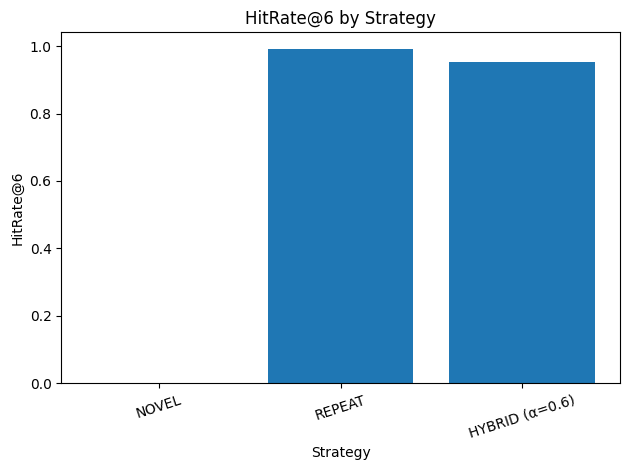

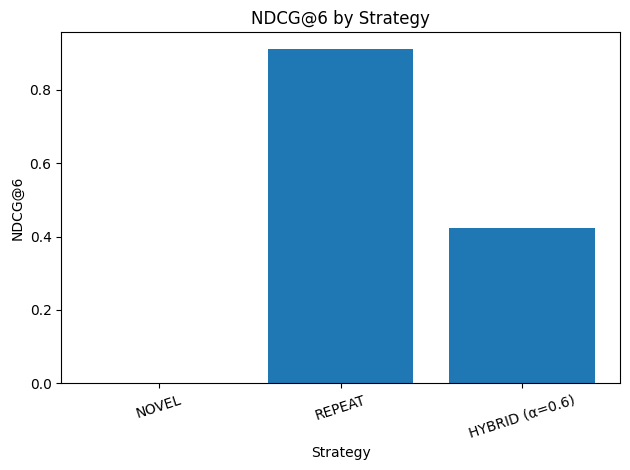

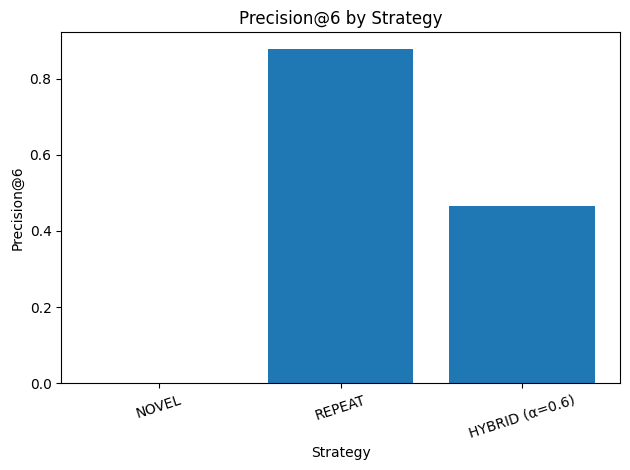

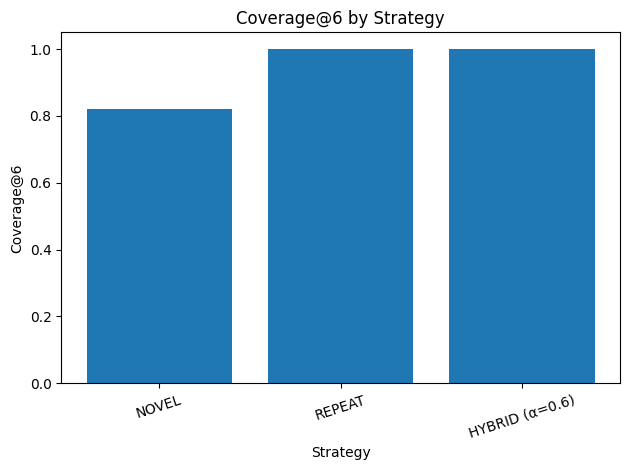

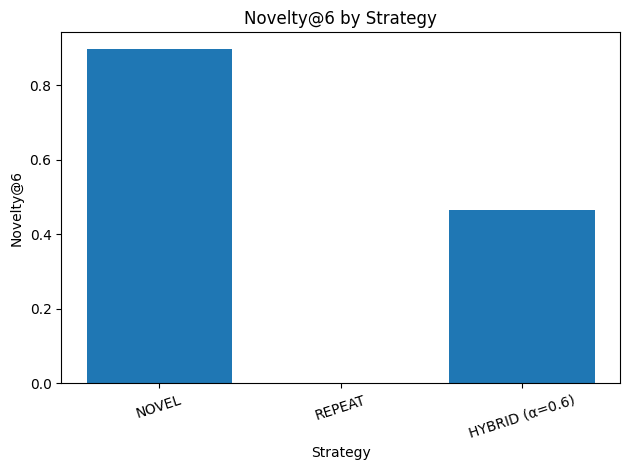

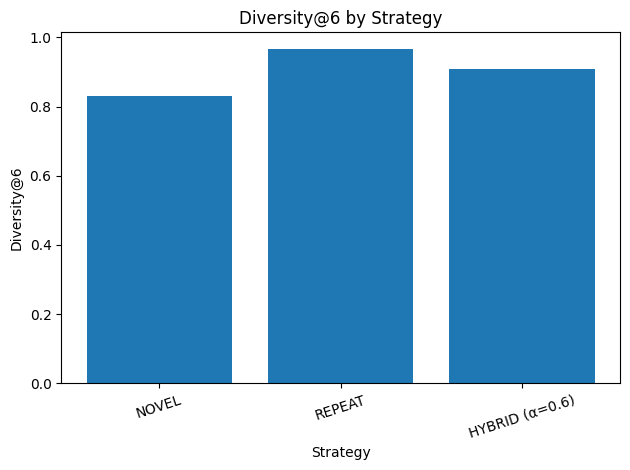

In [ ]:
random.seed(42)
K = 6
alpha = 0.6
sample_size = 2000
COMPUTE_DIVERSITY = True  # set False to skip Diversity@K
SAVE_SUMMARY = False      # set True and adjust path to export CSV

# Use filtered product_to_users if available
if "product_to_users" not in globals():
    product_to_users = {}

sample_users = random.sample(
    list(users_with_future),
    min(sample_size, len(users_with_future))
)

def _recommended_list_from_recs(recs):
    """Return ordered list of item names from recommender output."""
    return [r["recommended_item"] for r in (recs or [])]

def _recommended_set_from_recs(recs):
    """Return set of item names from recommender output."""
    return set(_recommended_list_from_recs(recs))

def _future_purchased_names(user_id):
    """Products bought by the user in TRAIN (as names)."""
    if user_id not in future_baskets:
        return set()
    return {id_to_name[p] for p in future_baskets[user_id] if p in id_to_name}

def _diversity_from_items(items):
    """Average 1 - Jaccard similarity over all item pairs in the recommendation list."""
    if not COMPUTE_DIVERSITY:
        return None
    items = list(items)
    if len(items) < 2:
        return 1.0
    distances = []
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            a, b = items[i], items[j]
            users_A = product_to_users.get(a, set())
            users_B = product_to_users.get(b, set())
            union = len(users_A | users_B)
            if union == 0:
                distances.append(1.0)
            else:
                inter = len(users_A & users_B)
                jaccard_sim = inter / union
                distances.append(1.0 - jaccard_sim)
    return (sum(distances) / len(distances)) if distances else 1.0

def _dcg_at_k(recommended_list, relevant_set, k):
    """Compute DCG@k given an ordered recommendation list and a set of relevant items."""
    dcg = 0.0
    for i, item in enumerate(recommended_list[:k], start=1):
        rel = 1.0 if item in relevant_set else 0.0
        if rel > 0:
            dcg += rel / math.log2(i + 1)
    return dcg

def _ndcg_at_k(recommended_list, relevant_set, k):
    """Compute NDCG@k with binary relevance."""
    if not relevant_set:
        return 0.0
    dcg = _dcg_at_k(recommended_list, relevant_set, k)
    max_rels = min(k, len(relevant_set))
    ideal_list = [1.0] * max_rels
    idcg = 0.0
    for i, rel in enumerate(ideal_list, start=1):
        idcg += rel / math.log2(i + 1)
    return dcg / idcg if idcg > 0 else 0.0

def _avg(xs):
    """Safe average ignoring None and NaN."""
    vals = []
    for x in xs:
        if x is None:
            continue
        try:
            if math.isnan(x):
                continue
        except TypeError:
            # Non-numeric values are ignored
            pass
        vals.append(float(x))
    return (sum(vals) / len(vals)) if vals else 0.0

# Metric collectors
novel_hit_rates, novel_ndcgs = [], []
novel_precisions, novel_novelties, novel_diversities = [], [], []

repeat_hit_rates, repeat_ndcgs = [], []
repeat_precisions, repeat_diversities = [], []

hybrid_hit_rates, hybrid_ndcgs = [], []
hybrid_precisions, hybrid_novelties, hybrid_diversities = [], [], []

novel_nonempty = repeat_nonempty = hybrid_nonempty = 0

for idx, uid in enumerate(sample_users, start=1):
    future_names = _future_purchased_names(uid)

    # === NOVEL (rules-based, no repeats) ===
    recs_novel = recommend_with_explanations(uid, top_k=K, allow_repeat=False)
    if recs_novel:
        novel_nonempty += 1
        rec_list = _recommended_list_from_recs(recs_novel)
        rec_set = set(rec_list)
        hits = rec_set & future_names

        novel_hit_rates.append(1.0 if hits else 0.0)
        novel_ndcgs.append(_ndcg_at_k(rec_list, future_names, K))
        novel_precisions.append(len(hits) / K)

        purchased_before = {
            id_to_name[x] for x in user_baskets.get(uid, set()) if x in id_to_name
        }
        novel_novelties.append(len(rec_set - purchased_before) / K)
        novel_diversities.append(_diversity_from_items(rec_list))
    else:
        novel_hit_rates.append(None)
        novel_ndcgs.append(None)
        novel_precisions.append(None)
        novel_novelties.append(None)
        novel_diversities.append(None)

    # === REPEAT (freq + recency) ===
    recs_repeat = recommend_repeats(uid, top_k=K)
    if recs_repeat:
        repeat_nonempty += 1
        rec_list = _recommended_list_from_recs(recs_repeat)
        rec_set = set(rec_list)
        hits = rec_set & future_names

        repeat_hit_rates.append(1.0 if hits else 0.0)
        repeat_ndcgs.append(_ndcg_at_k(rec_list, future_names, K))
        repeat_precisions.append(len(hits) / K)
        repeat_diversities.append(_diversity_from_items(rec_list))
    else:
        repeat_hit_rates.append(None)
        repeat_ndcgs.append(None)
        repeat_precisions.append(None)
        repeat_diversities.append(None)

    # === HYBRID (NOVEL + REPEAT) ===
    recs_hybrid = recommend_hybrid(uid, top_k=K, alpha=alpha)
    if recs_hybrid:
        hybrid_nonempty += 1
        rec_list = _recommended_list_from_recs(recs_hybrid)
        rec_set = set(rec_list)
        hits = rec_set & future_names

        hybrid_hit_rates.append(1.0 if hits else 0.0)
        hybrid_ndcgs.append(_ndcg_at_k(rec_list, future_names, K))
        hybrid_precisions.append(len(hits) / K)

        purchased_before = {
            id_to_name[x] for x in user_baskets.get(uid, set()) if x in id_to_name
        }
        hybrid_novelties.append(len(rec_set - purchased_before) / K)
        hybrid_diversities.append(_diversity_from_items(rec_list))
    else:
        hybrid_hit_rates.append(None)
        hybrid_ndcgs.append(None)
        hybrid_precisions.append(None)
        hybrid_novelties.append(None)
        hybrid_diversities.append(None)

    if idx % 50 == 0:
        print(f"Processed {idx}/{len(sample_users)} users...")

# Build summary table
rows = [
    [
        "NOVEL",
        round(_avg(novel_hit_rates), 4),
        round(_avg(novel_ndcgs), 4),
        round(_avg(novel_precisions), 4),
        round(novel_nonempty / len(sample_users), 4),
        round(_avg(novel_novelties), 4),
        round(_avg(novel_diversities), 4) if COMPUTE_DIVERSITY else None,
    ],
    [
        "REPEAT",
        round(_avg(repeat_hit_rates), 4),
        round(_avg(repeat_ndcgs), 4),
        round(_avg(repeat_precisions), 4),
        round(repeat_nonempty / len(sample_users), 4),
        0.0,  # novelty is by definition 0 for pure repeat recommendations
        round(_avg(repeat_diversities), 4) if COMPUTE_DIVERSITY else None,
    ],
    [
        f"HYBRID (α={alpha})",
        round(_avg(hybrid_hit_rates), 4),
        round(_avg(hybrid_ndcgs), 4),
        round(_avg(hybrid_precisions), 4),
        round(hybrid_nonempty / len(sample_users), 4),
        round(_avg(hybrid_novelties), 4),
        round(_avg(hybrid_diversities), 4) if COMPUTE_DIVERSITY else None,
    ],
]

cols = [
    "Strategy",
    f"HitRate@{K}",
    f"NDCG@{K}",
    f"Precision@{K}",
    f"Coverage@{K}",
    f"Novelty@{K}",
]
if COMPUTE_DIVERSITY:
    cols.append(f"Diversity@{K}")

summary = pd.DataFrame(rows, columns=cols)

print(f"\n=== COMPARISON @k={K} ===")
print(summary.to_string(index=False))

# Optional: save summary to CSV (adjust path as needed)
if SAVE_SUMMARY:
    out_path = "pcy_eval_summary_k6.csv"  # adjust to your project structure
    summary.to_csv(out_path, index=False)
    print(f"[saved] {out_path}")

# Bar charts (skip diversity if disabled)
plot_metrics = [
    f"HitRate@{K}",
    f"NDCG@{K}",
    f"Precision@{K}",
    f"Coverage@{K}",
    f"Novelty@{K}",
]
if COMPUTE_DIVERSITY:
    plot_metrics.append(f"Diversity@{K}")

for metric in plot_metrics:
    plt.figure()
    plt.title(f"{metric} by Strategy")
    plt.bar(summary["Strategy"], summary[metric])
    plt.xlabel("Strategy")
    plt.ylabel(metric)
    plt.xticks(rotation=18)
    plt.tight_layout()
    plt.show()


<h3>
  <span style="color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
    Random-User Demo: NOVEL / REPEAT / HYBRID with Explanations + Train Purchase Check (@k=6)
  </span>
</h3>

- Picks a random user (up to a few tries) and prints Top-6 recommendations for:
  - **NOVEL** (rules; excludes previously bought items),
  - **REPEAT** (frequency + recency based repeat model),
  - **HYBRID** (blend of NOVEL and REPEAT with weight `alpha`).
- For each recommended item, shows:
  - the **score**,
  - a compact **“why”** (short explanation),
  - whether it was **bought in TRAIN** (future purchases).
- Deterministic output formatting; falls back to another user if the first one yields empty lists.
- **Inputs:** `recommend_with_explanations`, `recommend_repeats`, `recommend_hybrid`, `user_baskets`, `future_baskets`, `id_to_name`, `users_with_future`.
- **Next cell:** optional visualization of these three lists (e.g., bar charts of scores per strategy).


In [16]:
alpha = 0.6   # weight for NOVEL inside HYBRID
K = 6         # top-K to display

def _future_bought_names(u: int):
    """Return the set of product names that the user bought in TRAIN."""
    return {
        id_to_name[p]
        for p in future_baskets.get(u, set())
        if p in id_to_name
    }

def _print_recs(title: str, recs, future_names):
    """Pretty-print a recommendation list with explanations and TRAIN check."""
    print(f"\n--- {title} ---\n")
    if not recs:
        print("(no recommendations)")
        return

    for r in recs:
        # Support both dict-style and (item, score) tuples
        if isinstance(r, dict):
            item = r.get("recommended_item")
            score = r.get("score", 0.0)
            exps = r.get("explanations", [])
        else:
            item, score = r[0], r[1]
            exps = []

        print("Recommended:", item)
        print("Score:", round(float(score), 3))

        if exps:
            print("Why:")
            for e in exps:
                print("  -", e)

        bought_flag = "YES" if item in future_names else "NO"
        print(f"Bought in TRAIN: {bought_flag}")
        print()

# Try a few random users to avoid one with empty recs for all strategies
example_user = None
for _ in range(10):
    cand = random.choice(list(users_with_future))
    has_any = (
        recommend_with_explanations(cand, top_k=K, allow_repeat=False)
        or recommend_repeats(cand, top_k=K)
        or recommend_hybrid(cand, top_k=K, alpha=alpha)
    )
    if has_any:
        example_user = cand
        break

# Final fallback: any user with future purchases
if example_user is None:
    example_user = random.choice(list(users_with_future))

print("Example user_id:", example_user)
future_purchased_names = _future_bought_names(example_user)

# NOVEL (rules, excludes items the user already bought)
recs_novel = recommend_with_explanations(
    example_user, top_k=K, allow_repeat=False
)
_print_recs("NOVEL (Rules, no repeat)", recs_novel, future_purchased_names)

# REPEAT (already-bought items ranked by frequency + recency)
recs_repeat = recommend_repeats(example_user, top_k=K)
_print_recs("REPEAT (Frequency/Recency)", recs_repeat, future_purchased_names)

# HYBRID (blend of NOVEL and REPEAT using alpha)
recs_hybrid = recommend_hybrid(example_user, top_k=K, alpha=alpha)
_print_recs(f"HYBRID (alpha={alpha})", recs_hybrid, future_purchased_names)


Example user_id: 114756

--- NOVEL (Rules, no repeat) ---

Recommended: Organic Hass Avocado
Score: 7.57
Why:
  - because you bought 'Organic Baby Spinach' (lift=2.37, confidence=0.15)
  - because you bought 'Organic Zucchini' (lift=2.57, confidence=0.16)
  - because you bought 'Organic Garlic' (lift=2.63, confidence=0.16)
Bought in TRAIN: NO

Recommended: Banana
Score: 5.91
Why:
  - because you bought 'Blueberries' (lift=2.16, confidence=0.29)
  - because you bought 'Organic Baby Spinach' (lift=1.58, confidence=0.21)
  - because you bought 'Yellow Onions' (lift=2.17, confidence=0.29)
Bought in TRAIN: NO

Recommended: Organic Yellow Onion
Score: 2.526
Why:
  - because you bought 'Organic Baby Spinach' (lift=2.53, confidence=0.08)
Bought in TRAIN: NO

Recommended: Limes
Score: 2.15
Why:
  - because you bought 'Organic Baby Spinach' (lift=2.15, confidence=0.09)
Bought in TRAIN: NO

Recommended: Organic Raspberries
Score: 1.906
Why:
  - because you bought 'Organic Baby Spinach' (lift=1.91

<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Visualization: NOVEL / REPEAT / HYBRID Recommendations for Random User
</span></h3>

- Builds tidy `df_viz` for the three strategies and flags **bought in TRAIN**.  
- Draws one horizontal bar chart per strategy; labels include a **✓** when bought.  
- Adds a combined chart with scores **normalized to [0,1] per strategy** for side-by-side comparison.  
- Safe when any list is empty (skips its chart).  
- **Inputs:** `recs_novel`, `recs_repeat`, `recs_hybrid`, `future_purchased_names`. **Output:** quick visual audit.


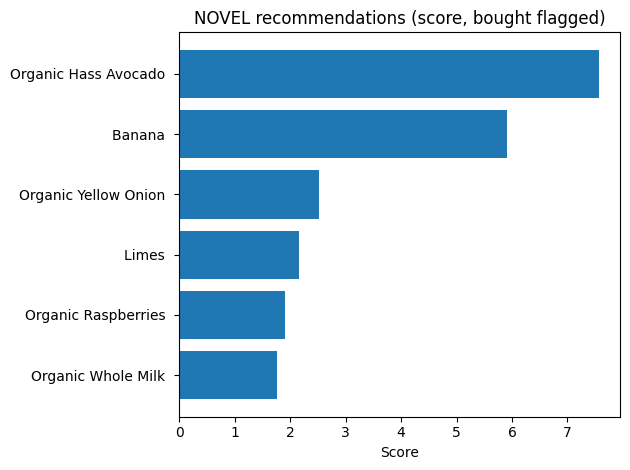

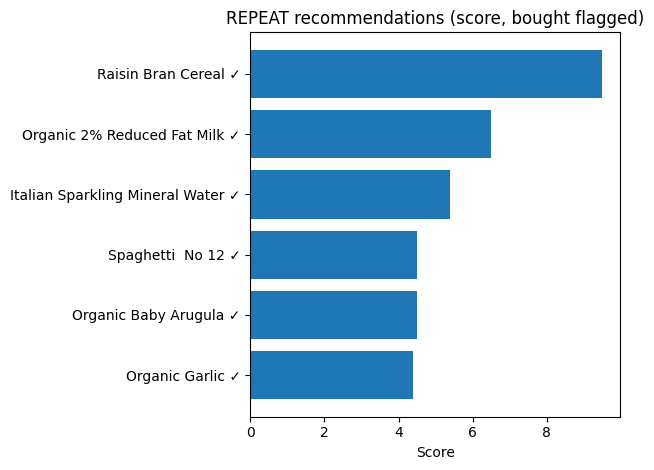

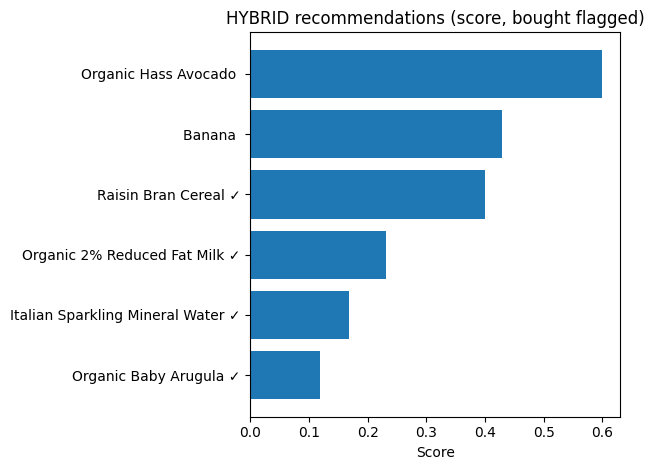

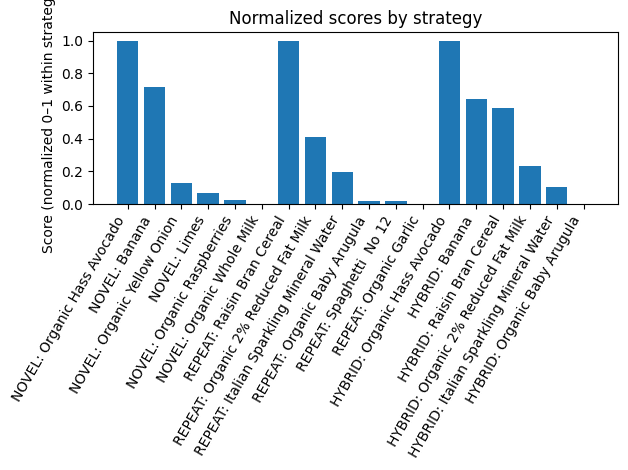

In [17]:
def _to_df(strategy_name, recs, future_names):
    """Convert recs to a tidy DataFrame."""
    rows = []
    for r in (recs or []):
        item = r["recommended_item"] if isinstance(r, dict) else r[0]
        score = float(r["score"] if isinstance(r, dict) else r[1])
        bought = item in future_names
        rows.append({"strategy": strategy_name, "item": item, "score": score, "bought": bought})
    return pd.DataFrame(rows)

# Build one DataFrame (skip empties safely)
parts = []
parts.append(_to_df("NOVEL",  recs_novel,  future_purchased_names))
parts.append(_to_df("REPEAT", recs_repeat, future_purchased_names))
parts.append(_to_df("HYBRID", recs_hybrid, future_purchased_names))
df_viz = pd.concat([p for p in parts if not p.empty], ignore_index=True) if any(not p.empty for p in parts) else pd.DataFrame(columns=["strategy","item","score","bought"])

def _plot_strategy(df, strategy):
    d = df[df["strategy"] == strategy].copy()
    if d.empty:
        print(f"No data for {strategy}")
        return
    d = d.sort_values("score", ascending=True)
    plt.figure()
    plt.title(f"{strategy} recommendations (score, bought flagged)")
    labels = [f"{it} {'✓' if b else ''}" for it, b in zip(d["item"], d["bought"])]
    plt.barh(labels, d["score"])
    plt.xlabel("Score")
    plt.tight_layout()
    plt.show()

# Plot per strategy
_plot_strategy(df_viz, "NOVEL")
_plot_strategy(df_viz, "REPEAT")
_plot_strategy(df_viz, "HYBRID")

def _normalize_scores_per_strategy(df):
    """Add score_norm ∈ [0,1] within each strategy."""
    if df.empty:
        return df.assign(score_norm=[])
    out = df.copy()
    out["score_norm"] = 0.0
    for s in out["strategy"].unique():
        mask = (out["strategy"] == s)
        vmin = out.loc[mask, "score"].min()
        vmax = out.loc[mask, "score"].max()
        if vmax == vmin:
            out.loc[mask, "score_norm"] = 1.0
        else:
            out.loc[mask, "score_norm"] = (out.loc[mask, "score"] - vmin) / (vmax - vmin)
    return out

df_norm = _normalize_scores_per_strategy(df_viz)

# Plot combined normalized scores (stacked by strategy blocks)
if not df_norm.empty:
    plt.figure()
    plt.title("Normalized scores by strategy")
    x_labels = [f"{s}: {it}" for s, it in zip(df_norm["strategy"], df_norm["item"])]
    plt.bar(x_labels, df_norm["score_norm"])
    plt.ylabel("Score (normalized 0–1 within strategy)")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize (all strategies empty).")


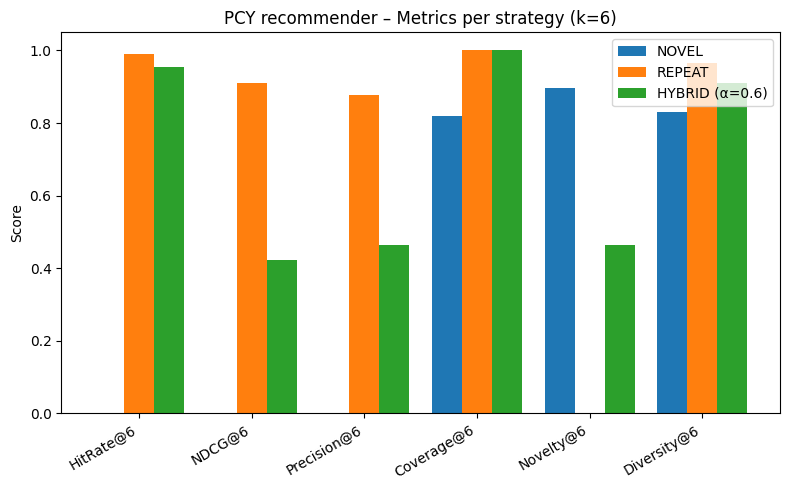

In [ ]:
# ΧUses matplotlib to create a grouped bar chart from the summary DataFrame
# Columns: ["Strategy", "HitRate@6", "NDCG@6", "Precision@6",
#           "Coverage@6", "Novelty@6", "Diversity@6"]

metrics = [
    col for col in summary.columns
    if col != "Strategy"
]

n_metrics = len(metrics)
strategies = summary["Strategy"].tolist()
n_strat = len(strategies)

x = np.arange(n_metrics)
width = 0.8 / n_strat  # total width divided by number of strategies

plt.figure(figsize=(8, 5))

for i, strat in enumerate(strategies):
    values = summary.loc[summary["Strategy"] == strat, metrics].values[0]
    # offset for each strategy
    offset = (i - (n_strat - 1) / 2) * width
    plt.bar(x + offset, values, width, label=strat)

plt.xticks(x, metrics, rotation=30, ha="right")
plt.ylabel("Score")
plt.title("PCY recommender – Metrics per strategy (k=6)")
plt.legend()
plt.tight_layout()
plt.show()

<h3>
  <span style="color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
    Alpha Tuning for HYBRID (Grid Search with Precision/Coverage/Novelty/Fβ) @k=6
  </span>
</h3>

- Sweeps `alpha ∈ [0,1]` and evaluates the **HYBRID** recommender on a sampled user set  
  (or FULL SCAN by uncommenting the relevant line).
- Per-α metrics:
  - **Precision@6** – hits in TRAIN / 6
  - **Coverage@6** – share of users with ≥1 non-empty recommendation list
  - **Novelty@6** – share of recommended items not seen in PRIOR
  - Optional **Diversity@6** – mean (1 − Jaccard) over recommended item pairs  
    (uses the filtered `product_to_users`)
  - **Fβ** – scalar trade-off between Precision and Novelty (`β < 1` favors precision, `β > 1` favors novelty)
- Prints a summary table + metric-vs-α plots; reports best α per objective.
- Reproducible via `seed`; deterministic `alpha` grid.
- **Inputs:** `recommend_hybrid`, `users_with_future`, `user_baskets`, `future_baskets`, `id_to_name`
  (and `product_to_users` if diversity is enabled).
- **Outputs:** `summary` DataFrame (metrics per α) + console report + plots.


=== Alpha Tuning Summary (@k=6) ===
(seed=42, sample_size=2000, beta=0.5, diversity=False)
 alpha  Precision@6  Coverage@6  Novelty@6   F0.5
  0.00       0.8602         1.0     0.0617 0.2396
  0.05       0.8457         1.0     0.0767 0.2813
  0.10       0.8352         1.0     0.0873 0.3079
  0.15       0.8202         1.0     0.1028 0.3424
  0.20       0.7972         1.0     0.1261 0.3861
  0.25       0.7681         1.0     0.1557 0.4299
  0.30       0.7267         1.0     0.1985 0.4743
  0.35       0.6807         1.0     0.2454 0.5024
  0.40       0.6376         1.0     0.2891 0.5137
  0.45       0.5963         1.0     0.3308 0.5139
  0.50       0.5567         1.0     0.3711 0.5061
  0.55       0.5149         1.0     0.4138 0.4909
  0.60       0.4650         1.0     0.4644 0.4649
  0.65       0.4162         1.0     0.5138 0.4327
  0.70       0.3627         1.0     0.5680 0.3909
  0.75       0.3190         1.0     0.6125 0.3528
  0.80       0.2819         1.0     0.6500 0.3179
  0.85   

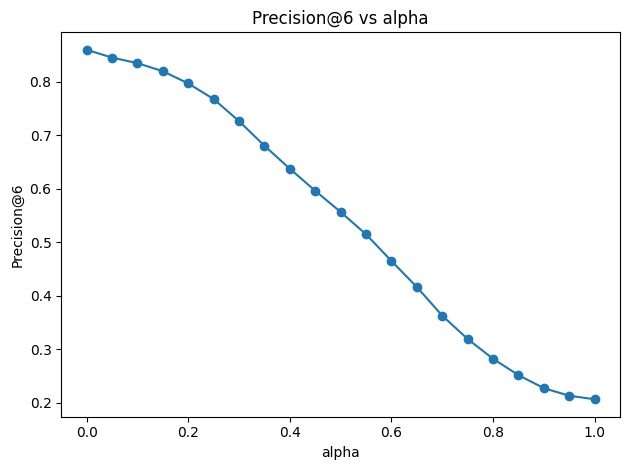

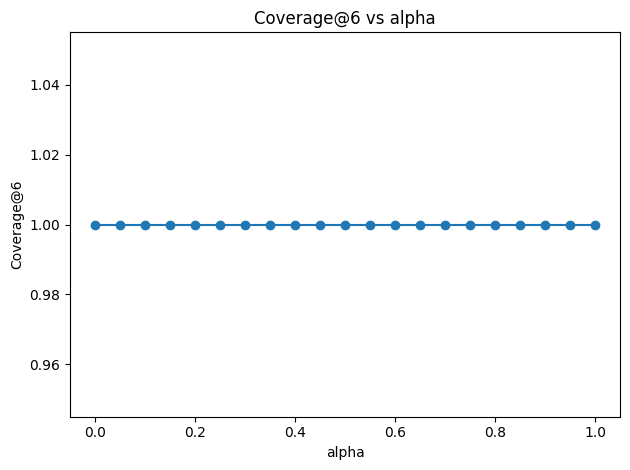

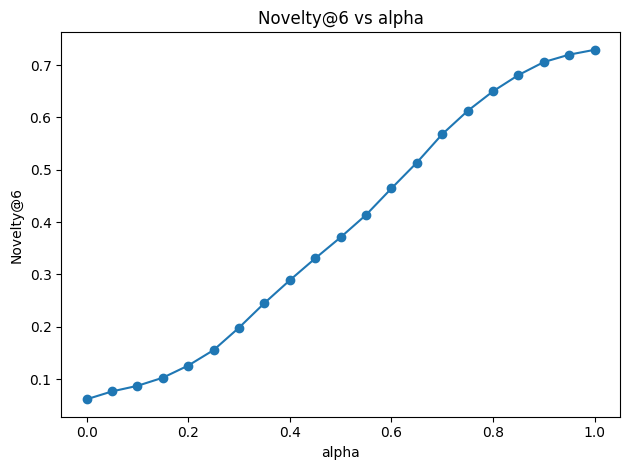

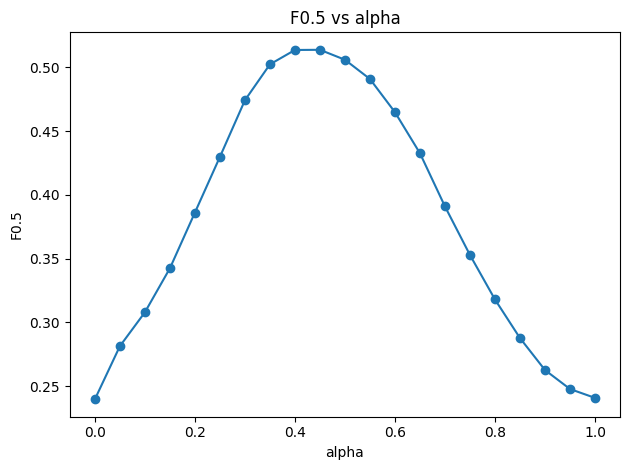

In [19]:
# Alpha tuning config
K = 6
seed = 42
sample_size = 2000
alphas = np.round(np.linspace(0.0, 1.0, 21), 2)  # 0.00 .. 1.00
beta = 0.5  # F_beta: <1 favors precision, >1 favors novelty
COMPUTE_DIVERSITY = False  # set True to include Diversity@K (requires product_to_users)

random.seed(seed)

# Choose evaluation population (use ONE of the following lines)
# sample_users = list(users_with_future)  # FULL SCAN
sample_users = random.sample(
    list(users_with_future),
    min(sample_size, len(users_with_future))
)  # SAMPLE (default)

# Ensure product_to_users exists if diversity is enabled
if COMPUTE_DIVERSITY and "product_to_users" not in globals():
    product_to_users = {}

# Helpers
def _recommended_set_from_recs(recs):
    """Return set of item names from recommender output (dict-style)."""
    return {r["recommended_item"] for r in (recs or [])}

def _future_purchased_names(user_id):
    """Products bought by the user in TRAIN (as names)."""
    if user_id not in future_baskets:
        return set()
    return {
        id_to_name[p]
        for p in future_baskets[user_id]
        if p in id_to_name
    }

def _diversity_from_items(items):
    """Average 1 - Jaccard similarity across item pairs in the recommendation list."""
    if not COMPUTE_DIVERSITY:
        return None
    items = list(items)
    if len(items) < 2:
        return 1.0
    distances = []
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            a, b = items[i], items[j]
            users_A = product_to_users.get(a, set())
            users_B = product_to_users.get(b, set())
            u = len(users_A | users_B)
            if u == 0:
                distances.append(1.0)
            else:
                inter = len(users_A & users_B)
                distances.append(1.0 - inter / u)
    return (sum(distances) / len(distances)) if distances else 1.0

def _avg(xs):
    """Safe average ignoring None and NaN."""
    vals = []
    for x in xs:
        if x is None:
            continue
        try:
            if math.isnan(x):
                continue
        except TypeError:
            # Non-numeric values are ignored
            pass
        vals.append(float(x))
    return (sum(vals) / len(vals)) if vals else 0.0

def _f_beta(p, n, beta):
    """
    F_beta-style trade-off between precision (p) and novelty (n).
    beta < 1.0 -> emphasize precision
    beta > 1.0 -> emphasize novelty
    """
    if p == 0 and n == 0:
        return 0.0
    b2 = beta * beta
    denom = b2 * p + n
    return (1 + b2) * (p * n) / denom if denom > 0 else 0.0

# Evaluate each alpha
rows = []

for a in alphas:
    precs, novs, divs = [], [], []
    nonempty = 0

    for uid in sample_users:
        recs = recommend_hybrid(uid, top_k=K, alpha=float(a))
        if not recs:
            precs.append(None)
            novs.append(None)
            divs.append(None)
            continue

        nonempty += 1
        items = _recommended_set_from_recs(recs)
        fut = _future_purchased_names(uid)

        # Precision@K
        p = len(items & fut) / K

        # Novelty@K (share of items NOT seen in PRIOR)
        prior_names = {
            id_to_name[x]
            for x in user_baskets.get(uid, set())
            if x in id_to_name
        }
        n = len(items - prior_names) / K

        # Diversity@K (optional)
        d = _diversity_from_items(items)

        precs.append(p)
        novs.append(n)
        divs.append(d)

    P = _avg(precs)
    N = _avg(novs)
    D = _avg(divs) if COMPUTE_DIVERSITY else None
    C = nonempty / len(sample_users) if sample_users else 0.0
    F = _f_beta(P, N, beta)

    row = {
        "alpha": float(a),
        f"Precision@{K}": P,
        f"Coverage@{K}": C,
        f"Novelty@{K}": N,
        f"F{beta}": F,
    }
    if COMPUTE_DIVERSITY:
        row[f"Diversity@{K}"] = D

    rows.append(row)

summary = pd.DataFrame(rows)

# Best alphas per objective
best_precision_alpha = summary.loc[summary[f"Precision@{K}"].idxmax(), "alpha"]
best_novelty_alpha   = summary.loc[summary[f"Novelty@{K}"].idxmax(),   "alpha"]
best_coverage_alpha  = summary.loc[summary[f"Coverage@{K}"].idxmax(),  "alpha"]
best_fbeta_alpha     = summary.loc[summary[f"F{beta}"].idxmax(),       "alpha"]
best_diversity_alpha = None
if COMPUTE_DIVERSITY and f"Diversity@{K}" in summary.columns:
    best_diversity_alpha = summary.loc[summary[f"Diversity@{K}"].idxmax(), "alpha"]

print(f"=== Alpha Tuning Summary (@k={K}) ===")
print(f"(seed={seed}, sample_size={len(sample_users)}, beta={beta}, diversity={COMPUTE_DIVERSITY})")
print(summary.round(4).to_string(index=False))

print("\nBest alpha per objective:")
print(f"- Precision@{K} : {best_precision_alpha}")
print(f"- Novelty@{K}   : {best_novelty_alpha}")
print(f"- Coverage@{K}  : {best_coverage_alpha}")
if COMPUTE_DIVERSITY and best_diversity_alpha is not None:
    print(f"- Diversity@{K} : {best_diversity_alpha}")
print(f"- F{beta} (trade-off P vs N): {best_fbeta_alpha}")

# Plots
plot_metrics = [
    f"Precision@{K}",
    f"Coverage@{K}",
    f"Novelty@{K}",
    f"F{beta}",
]
if COMPUTE_DIVERSITY:
    # If diversity is enabled, put it before F-beta (optional)
    plot_metrics.insert(3, f"Diversity@{K}")

for metric in plot_metrics:
    plt.figure()
    plt.title(f"{metric} vs alpha")
    plt.plot(summary["alpha"], summary[metric], marker="o")
    plt.xlabel("alpha")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()


In [ ]:
metrics_to_plot = [
    f"Precision@{K}",
    f"Novelty@{K}",
    f"F{beta}",
]

plt.figure(figsize=(7, 4))

for m in metrics_to_plot:
    plt.plot(
        summary["alpha"],
        summary[m],
        marker="o",
        label=m,
    )

best_alpha = 0.45
plt.axvline(best_alpha, linestyle="--")
plt.text(
    best_alpha,
    summary[f"F{beta}"].max(),
    f"  α={best_alpha}",
    va="bottom"
)

plt.xlabel("α")
plt.ylabel("Score")
plt.title(f"HYBRID recommender – metrics vs α (k={K})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<h3>
  <span style="color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
    Reusable Adaptive-4Seg Runner + Factory (no global mutations) @k=6
  </span>
</h3>

- **`run_adaptive_4seg(...)`**: Encapsulates the full pipeline:
  1) Per-user grid-search over `alpha ∈ [0,1]` to find best α by **`precision`** or **`Fβ`**.  
  2) Computes each user’s **repeat_ratio** and assigns them to **4 quantile segments** (explorer, light-mixed, heavy-mixed, repeater).  
  3) Produces **segment-level α** as the **median** of per-user best α per segment.  
  4) Returns artifacts (`adaptive_df`, `segment_alpha`, `quantiles`, `config`) **without editing globals**.
- **`make_adaptive_recommender(...)`**: Factory that returns a callable recommender using the learned **4-segment α**.  
  - Given a `user_id`, it computes `repeat_ratio`, picks the segment, applies its α, calls `recommend_hybrid`, and appends a short **rationale** to explanations.
- **Why**: Lets us run **multiple experiments** (e.g., baseline precision vs Fβ) in new cells **without** touching previous code or states.  
- **Inputs:** `recommend_hybrid`, `users_with_future`, `user_baskets`, `future_baskets`, `id_to_name`.  
- **Outputs:** `adaptive_df` (per-user best α, precision, novelty, repeat_ratio), `segment_alpha`, `quantiles`, `config`; plus an **adaptive recommender** ready for inference.


In [20]:
def run_adaptive_4seg(
    *,
    recommend_hybrid,                 # callable(user_id, top_k, alpha)
    users_with_future,
    user_baskets,
    future_baskets,
    id_to_name,
    k: int = 6,
    seed: int = 42,
    sample_size: int | None = 5000,
    sample_users: list[int] | None = None,
    alpha_grid=None,                  # e.g. np.round(np.linspace(0,1,21),2)
    opt_metric: str = "precision",    # or "fbeta"
    beta: float = 1.0                 # used only if opt_metric == "fbeta"
):
    """
    Run per-user alpha grid-search, 4-quantile segmentation on repeat_ratio,
    and return artifacts without mutating global state.
    """
    rng = random.Random(seed)

    # Choose which users to evaluate
    if sample_users is None:
        pop = list(users_with_future)
        if sample_size is None or sample_size >= len(pop):
            sample_users = pop
        else:
            sample_users = rng.sample(pop, sample_size)

    # Default alpha grid
    if alpha_grid is None:
        alpha_grid = np.round(np.linspace(0.0, 1.0, 21), 2)

    def _recommended_set_from_recs(recs):
        return {r["recommended_item"] for r in (recs or [])}

    def _future_purchased_names(user_id):
        if user_id not in future_baskets:
            return set()
        return {
            id_to_name[p]
            for p in future_baskets[user_id]
            if p in id_to_name
        }

    def _repeat_ratio(user_id):
        prior = {
            id_to_name[x]
            for x in user_baskets.get(user_id, set())
            if x in id_to_name
        }
        fut = _future_purchased_names(user_id)
        return (len(prior & fut) / len(fut)) if fut else 0.0

    def _fbeta(p, n, beta_):
        if p == 0 and n == 0:
            return 0.0
        b2 = beta_ * beta_
        denom = b2 * p + n
        return (1 + b2) * (p * n) / denom if denom > 0 else 0.0

    rows = []

    for uid in sample_users:
        fut = _future_purchased_names(uid)
        if not fut:
            continue

        best_a, best_val = None, -1.0
        best_p, best_n = 0.0, 0.0

        for a in alpha_grid:
            recs = recommend_hybrid(uid, top_k=k, alpha=float(a))
            if not recs:
                continue

            items = _recommended_set_from_recs(recs)
            p = len(items & fut) / k

            prior_names = {
                id_to_name[x]
                for x in user_baskets.get(uid, set())
                if x in id_to_name
            }
            n = len(items - prior_names) / k

            if opt_metric == "precision":
                val = p
            else:
                val = _fbeta(p, n, beta)

            if val > best_val:
                best_val = val
                best_a = float(a)
                best_p, best_n = p, n

        if best_a is None:
            continue

        rows.append(
            {
                "user_id": uid,
                "best_alpha": best_a,
                "best_val": best_val,
                "best_precision": best_p,
                "best_novelty": best_n,
                "repeat_ratio": _repeat_ratio(uid),
            }
        )

    adaptive_df = pd.DataFrame(rows)

    # Edge case: no valid users
    if adaptive_df.empty:
        return {
            "adaptive_df": adaptive_df,
            "segment_alpha": {},
            "quantiles": {},
            "config": {
                "k": k,
                "seed": seed,
                "sample_size": sample_size,
                "alpha_grid": list(map(float, alpha_grid)),
                "opt_metric": opt_metric,
                "beta": beta,
                "evaluated_users": 0,
            },
        }

    # Quantiles on repeat_ratio
    qs = adaptive_df["repeat_ratio"].quantile([0.25, 0.50, 0.75]).to_dict()
    q25, q50, q75 = qs[0.25], qs[0.50], qs[0.75]

    def _segment4(rr: float) -> str:
        if rr <= q25:
            return "explorer"
        if rr <= q50:
            return "light-mixed"
        if rr <= q75:
            return "heavy-mixed"
        return "repeater"

    adaptive_df["segment"] = adaptive_df["repeat_ratio"].apply(_segment4)

    # Segment-level alpha = median user-level best_alpha
    segment_alpha = (
        adaptive_df.groupby("segment")["best_alpha"]
        .median()
        .to_dict()
    )

    return {
        "adaptive_df": adaptive_df,
        "segment_alpha": segment_alpha,
        "quantiles": {"q25": float(q25), "q50": float(q50), "q75": float(q75)},
        "config": {
            "k": k,
            "seed": seed,
            "sample_size": sample_size,
            "alpha_grid": list(map(float, alpha_grid)),
            "opt_metric": opt_metric,
            "beta": beta,
            "evaluated_users": int(adaptive_df["user_id"].nunique()),
        },
    }


def make_adaptive_recommender(
    segment_alpha: dict,
    quantiles: dict,
    *,
    default_alpha: float = 0.5,
):
    """
    Factory that returns a callable(user_id, top_k, recommend_hybrid, ...)
    which picks alpha based on 4-quantile repeat_ratio segments.
    """
    q25 = quantiles.get("q25", 0.25)
    q50 = quantiles.get("q50", 0.50)
    q75 = quantiles.get("q75", 0.75)

    def _adaptive(
        user_id: int,
        *,
        recommend_hybrid,
        user_baskets,
        future_baskets,
        id_to_name,
        top_k: int = 6,
    ):
        def _future_bought(u: int):
            if u not in future_baskets:
                return set()
            return {
                id_to_name[p]
                for p in future_baskets[u]
                if p in id_to_name
            }

        prior = {
            id_to_name[x]
            for x in user_baskets.get(user_id, set())
            if x in id_to_name
        }
        fut = _future_bought(user_id)
        rr = (len(prior & fut) / len(fut)) if fut else 0.0

        if rr <= q25:
            seg = "explorer"
        elif rr <= q50:
            seg = "light-mixed"
        elif rr <= q75:
            seg = "heavy-mixed"
        else:
            seg = "repeater"

        a = float(segment_alpha.get(seg, default_alpha))

        recs = recommend_hybrid(user_id, top_k=top_k, alpha=a)

        # Append short rationale to explanations
        for r in recs:
            r.setdefault("explanations", []).append(
                f"(adaptive-4seg) segment={seg}, alpha={a:.2f}, rr={rr:.2f}"
            )

        return recs

    return _adaptive


<h3>
  <span style="color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
    Baseline vs Fβ runs + segment α deltas + mean(best_precision/novelty) per run (@k=6)
  </span>
</h3>

- Runs `run_adaptive_4seg` twice: a **precision-only baseline** and an **Fβ run (β = 1.0)**.  
- Prints, for each run:
  - quantiles of **repeat_ratio**,
  - segment-level **α medians** (explorer / light-mixed / heavy-mixed / repeater).
- Compares runs with:
  - **Δα per segment** (α_Fβ − α_precision),
  - **mean(best_precision)** and **mean(best_novelty)** across users for each run.
- Uses existing `run_adaptive_4seg` (and can be combined with `make_adaptive_recommender`); no globals are mutated.


In [21]:
# Baseline: precision-only
res_prec = run_adaptive_4seg(
    recommend_hybrid=recommend_hybrid,
    users_with_future=users_with_future,
    user_baskets=user_baskets,
    future_baskets=future_baskets,
    id_to_name=id_to_name,
    k=6,
    seed=42,
    sample_size=5000,
    alpha_grid=np.round(np.linspace(0.0, 1.0, 21), 2),
    opt_metric="precision",  # beta ignored in this mode
    beta=1.0
)

print("=== Baseline (precision) ===")
print("Users evaluated:", res_prec["config"]["evaluated_users"])
print("Quantiles:", {k: round(v, 4) for k, v in res_prec["quantiles"].items()})
print("Segment α:", {k: round(v, 2) for k, v in res_prec["segment_alpha"].items()})

# Fβ run (β = 1.0)
res_fbeta = run_adaptive_4seg(
    recommend_hybrid=recommend_hybrid,
    users_with_future=users_with_future,
    user_baskets=user_baskets,
    future_baskets=future_baskets,
    id_to_name=id_to_name,
    k=6,
    seed=42,
    sample_size=5000,
    alpha_grid=np.round(np.linspace(0.0, 1.0, 21), 2),
    opt_metric="fbeta",
    beta=1.0
)

print("\n=== Fβ run (beta=1.0) ===")
print("Users evaluated:", res_fbeta["config"]["evaluated_users"])
print("Quantiles:", {k: round(v, 4) for k, v in res_fbeta["quantiles"].items()})
print("Segment α:", {k: round(v, 2) for k, v in res_fbeta["segment_alpha"].items()})

# Segment α side-by-side deltas
segments = sorted(
    set(res_prec["segment_alpha"]) | set(res_fbeta["segment_alpha"])
)

cmp = pd.DataFrame({
    "segment": segments,
    "alpha_precision": [
        res_prec["segment_alpha"].get(s, np.nan) for s in segments
    ],
    "alpha_fbeta": [
        res_fbeta["segment_alpha"].get(s, np.nan) for s in segments
    ],
})

cmp["delta"] = (cmp["alpha_fbeta"] - cmp["alpha_precision"]).round(3)

print("\n=== Segment α comparison ===")
print(cmp.to_string(index=False))

# Mean(best_precision) & Mean(best_novelty) per run
def _mean_safe(series_like):
    s = pd.Series(series_like).dropna()
    return float(s.mean()) if not s.empty else float("nan")

def _summarize_means(tag, df):
    mp = _mean_safe(df.get("best_precision", pd.Series(dtype=float)))
    mn = _mean_safe(df.get("best_novelty", pd.Series(dtype=float)))
    return {
        "run": tag,
        "mean_best_precision": round(mp, 4),
        "mean_best_novelty": round(mn, 4),
    }

means_df = pd.DataFrame([
    _summarize_means("precision", res_prec["adaptive_df"]),
    _summarize_means("fbeta(β=1.0)", res_fbeta["adaptive_df"]),
])

print("\n=== Mean of per-user best metrics ===")
print(means_df.to_string(index=False))


=== Baseline (precision) ===
Users evaluated: 5000
Quantiles: {'q25': 1.0, 'q50': 1.0, 'q75': 1.0}
Segment α: {'explorer': 0.0}

=== Fβ run (beta=1.0) ===
Users evaluated: 5000
Quantiles: {'q25': 1.0, 'q50': 1.0, 'q75': 1.0}
Segment α: {'explorer': 0.4}

=== Segment α comparison ===
 segment  alpha_precision  alpha_fbeta  delta
explorer              0.0          0.4    0.4

=== Mean of per-user best metrics ===
         run  mean_best_precision  mean_best_novelty
   precision               0.8633             0.0612
fbeta(β=1.0)               0.5520             0.3781


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Time-Decay for Repeat Scoring (half-life by order index)
</span></h3>

- Adds exponential **recency weight**: `decay = 0.5 ** ((Umax - last_order_number)/HALFLIFE_ORDERS)`.  
- New repeat score: `score_repeat = freq * decay + RECENCY_LAMBDA * norm_last_onum`.  
- Toggle via `USE_TIME_DECAY`; no upstream changes required.


In [22]:
# --- Time-decay config ---
USE_TIME_DECAY = True
HALFLIFE_ORDERS = 4.0   # half-life in "order_number" units
RECENCY_LAMBDA = 0.5    # already used in your repeat score

def _compute_decay_series(df: pd.DataFrame) -> pd.Series:
    """Per-user exponential decay based on 'last_order_number'."""
    if df.empty:
        return pd.Series(dtype=float)
    u_max = df.groupby("user_id")["last_order_number"].transform("max")
    age = (u_max - df["last_order_number"]).astype(float)
    decay = 0.5 ** (age / max(HALFLIFE_ORDERS, 1e-6))
    return decay

def recommend_repeats(user_id: int, top_k: int = 6):
    """Repeat recommendations ranked by (freq * decay) + RECENCY_LAMBDA * norm_last_onum."""
    if user_id not in user_baskets:
        return []

    subset = user_item_stats[user_item_stats["user_id"] == user_id]

    # Fallback: if MIN_FREQ filtered everything, use unfiltered stats (freq>=1)
    if subset.empty and "user_item_stats_full" in globals():
        subset = user_item_stats_full[user_item_stats_full["user_id"] == user_id].copy()
        if subset.empty:
            return []
        # ensure norm_last_onum
        umin = subset["last_order_number"].min()
        umax = subset["last_order_number"].max()
        subset["norm_last_onum"] = (
            1.0 if umax == umin
            else (subset["last_order_number"] - umin) / (umax - umin)
        )
    elif subset.empty:
        return []

    tmp = subset.copy()

    if USE_TIME_DECAY:
        tmp["decay"] = _compute_decay_series(tmp)
        tmp["score_repeat"] = (
            tmp["freq"] * tmp["decay"]
            + RECENCY_LAMBDA * tmp["norm_last_onum"]
        )
    else:
        tmp["score_repeat"] = tmp["freq"] + RECENCY_LAMBDA * tmp["norm_last_onum"]

    tmp["__name"] = tmp["product_id"].apply(
        lambda pid: id_to_name.get(pid, f"product_id={pid}")
    )
    tmp = tmp.sort_values(
        ["score_repeat", "__name"], ascending=[False, True]
    ).head(top_k)

    results = []
    for _, row in tmp.iterrows():
        name = row["__name"]
        freq = int(row["freq"])
        recn = float(row["norm_last_onum"])
        parts = [f"you bought it {freq} times", f"recency={recn:.2f}"]
        if USE_TIME_DECAY:
            parts.append(f"decay={float(row['decay']):.2f}")
        results.append(
            {
                "recommended_item": name,
                "score": float(row["score_repeat"]),
                "explanations": [", ".join(parts)],
            }
        )
    return results


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Popularity Debias (cap/penalty for very popular items)
</span></h3>

- Computes item popularity from `product_to_users`.  
- Two modes:
  - **"filter"**: drop items above `pop_quantile` (e.g., top 5%).  
  - **"penalty"**: scale scores by `1 / (1 + γ·pop_norm)`.  
- Applies to any rec list; integrate before display/eval if desired.


In [23]:
# --- Popularity config ---
POP_CAP_MODE = "none"      # "none" | "filter" | "penalty"
POP_QUANTILE = 0.95        # used when POP_CAP_MODE="filter"
POP_PENALTY_GAMMA = 1.0    # used when POP_CAP_MODE="penalty"

# Build popularity dict once
_item_pop = {}
if "product_to_users" in globals() and product_to_users:
    _item_pop = {item: len(uids) for item, uids in product_to_users.items()}
    pops = list(_item_pop.values())
    _pmin, _pmax = min(pops), max(pops)
    _pop_q = np.quantile(pops, POP_QUANTILE) if pops else float("inf")
else:
    _pmin, _pmax, _pop_q = 0, 1, float("inf")

def _apply_popularity_cap(recs: list[dict]) -> list[dict]:
    """Apply popularity-based filter or penalty to a list of rec dicts."""
    if not recs or POP_CAP_MODE == "none":
        return recs

    if POP_CAP_MODE == "filter":
        out = []
        for r in recs:
            pop = _item_pop.get(r["recommended_item"], 0)
            if pop <= _pop_q:
                out.append(r)
        return out

    if POP_CAP_MODE == "penalty":
        out = []
        for r in recs:
            pop = _item_pop.get(r["recommended_item"], _pmin)
            pop_norm = 0.0 if _pmax == _pmin else (pop - _pmin) / (_pmax - _pmin)
            scale = 1.0 / (1.0 + POP_PENALTY_GAMMA * pop_norm)

            r2 = dict(r)
            r2["score"] = float(r["score"]) * float(scale)
            r2.setdefault("explanations", []).append(
                f"(pop penalty: scale={scale:.2f})"
            )
            out.append(r2)

        # keep deterministic order after score change
        return sorted(out, key=lambda x: (-x["score"], x["recommended_item"]))

    return recs

# Optional wrappers if you want to apply debias automatically:
def recommend_with_explanations_debiased(
    user_id: int, top_k: int = 6, allow_repeat: bool = False
):
    base = recommend_with_explanations(
        user_id, top_k=top_k, allow_repeat=allow_repeat
    )
    return _apply_popularity_cap(base)

def recommend_hybrid_debiased(
    user_id: int, top_k: int = 6, alpha: float = 0.6
):
    base = recommend_hybrid(user_id, top_k=top_k, alpha=alpha)
    return _apply_popularity_cap(base)


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Cold-Start Fallbacks (no PRIOR or empty recs)
</span></h3>

- Global **popular** fallback from PRIOR (`product_to_users`).  
- Strategy-level helpers return fallback when base recs are empty.  
- Keeps existing APIs intact; call these in demos/eval if you want safety.


In [24]:
# Precompute global popular list
if "product_to_users" in globals() and product_to_users:
    _global_pop = sorted(
        [
            {
                "recommended_item": it,
                "score": len(uids),
                "explanations": ["global popular"],
            }
            for it, uids in product_to_users.items()
        ],
        key=lambda x: (-x["score"], x["recommended_item"]),
    )
else:
    _global_pop = []

def _fallback_global_pop(top_k: int = 6):
    """Return top-K globally popular items as a fallback."""
    return _global_pop[:top_k] if _global_pop else []

def recommend_novel_with_fallback(user_id: int, top_k: int = 6):
    """NOVEL recommendations with global popularity fallback when empty."""
    recs = recommend_with_explanations(
        user_id, top_k=top_k, allow_repeat=False
    )
    return recs if recs else _fallback_global_pop(top_k)

def recommend_repeat_with_fallback(user_id: int, top_k: int = 6):
    """REPEAT recommendations with global popularity fallback when empty."""
    recs = recommend_repeats(user_id, top_k=top_k)
    return recs if recs else _fallback_global_pop(top_k)

def recommend_hybrid_with_fallback(
    user_id: int, top_k: int = 6, alpha: float = 0.6
):
    """HYBRID recommendations with global popularity fallback when empty."""
    recs = recommend_hybrid(user_id, top_k=top_k, alpha=alpha)
    return recs if recs else _fallback_global_pop(top_k)


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
PCY Footprint Diagnostics (collision & bitmap density)
</span></h3>

- Lightweight diagnostics if you have PCY artifacts in-memory.  
- Expected optional vars: `pcy_bucket_counts` (array-like), `bitmap` (0/1 list), `num_pairs_hashed`.  
- Prints collision proxy and density; safe if artifacts are missing.


In [25]:
def pcy_diagnostics(pcy_bucket_counts=None, bitmap=None, num_pairs_hashed=None):
    """Print simple diagnostics for PCY buckets: density, collisions, and load."""
    if pcy_bucket_counts is None or bitmap is None:
        print("[PCY] Artifacts not found. Provide pcy_bucket_counts (array-like) and bitmap (0/1).")
        return

    counts = np.asarray(pcy_bucket_counts, dtype=np.int64)
    bm = np.asarray(bitmap, dtype=np.int8)
    m = len(counts)

    if m == 0:
        print("[PCY] Empty bucket array.")
        return

    hot = int(bm.sum())
    cold = int(m - hot)
    density = hot / m
    nonzero = int((counts > 0).sum())
    collisions = int((counts >= 2).sum())
    hashed = int(num_pairs_hashed) if num_pairs_hashed is not None else int(counts.sum())

    print("=== PCY Footprint ===")
    print(f"Buckets           : {m}  | Hot (bitmap=1): {hot}  | Cold: {cold}  | Density: {density:.4f}")
    print(f"Nonzero buckets   : {nonzero}  | Collisions (>=2 in same bucket): {collisions}")
    print(f"Pairs hashed (est): {hashed}")
    print(f"Avg load per bucket: {counts.sum() / m:.3f}")
    if hot > 0:
        print(f"Avg load per HOT bucket: {counts[bm == 1].mean():.3f}")


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Exports for Report (CSV/JSON)
</span></h3>

- Saves key artifacts for your write-up: rules, eval summary, adaptive runs, and sample user viz.  
- Optional; skip any block if the variable doesn’t exist.


In [27]:
# Exports are optional; enable flags to write files
SAVE_RULES = True
SAVE_EVAL_SUMMARY = True
SAVE_ADAPTIVE = True
SAVE_SAMPLE_VIZ = True

# Base save directory (will be created if missing)
SAVE_DIR = os.path.normpath("../../data/Georgios/pcy_recommender")
os.makedirs(SAVE_DIR, exist_ok=True)

def _save_df(df, filename, msg=None):
    """Tiny helper to save a DataFrame safely."""
    full_path = os.path.join(SAVE_DIR, filename)
    df.to_csv(full_path, index=False)
    print(f"[saved] {full_path}" if msg is None else f"[saved] {full_path}  | {msg}")

# 1) Rules
if SAVE_RULES and "df_rules_dedup" in globals():
    _save_df(df_rules_dedup, "rules_dedup.csv")

# 2) Evaluation summary (@k=6 from your eval cell)
if SAVE_EVAL_SUMMARY and "summary" in globals():
    _save_df(summary, "eval_comparison_k6.csv")

# 3) Adaptive runs (if you ran them)
if SAVE_ADAPTIVE and "res_prec" in globals() and "res_fbeta" in globals():
    _save_df(res_prec["adaptive_df"], "adaptive_precision.csv")
    _save_df(res_fbeta["adaptive_df"], "adaptive_fbeta_b1.csv")

    seg_prec = pd.DataFrame(
        [{"segment": k, "alpha": v} for k, v in res_prec["segment_alpha"].items()]
    )
    seg_fbeta = pd.DataFrame(
        [{"segment": k, "alpha": v} for k, v in res_fbeta["segment_alpha"].items()]
    )
    _save_df(seg_prec,  "seg_alpha_precision.csv")
    _save_df(seg_fbeta, "seg_alpha_fbeta_b1.csv")
    print("[saved] adaptive_* and seg_alpha_*")

# 4) Random-user viz data
if SAVE_SAMPLE_VIZ and "df_viz" in globals():
    _save_df(df_viz, "sample_user_viz.csv")


[saved] ..\..\data\Georgios\pcy_recommender\rules_dedup.csv
[saved] ..\..\data\Georgios\pcy_recommender\eval_comparison_k6.csv
[saved] ..\..\data\Georgios\pcy_recommender\adaptive_precision.csv
[saved] ..\..\data\Georgios\pcy_recommender\adaptive_fbeta_b1.csv
[saved] ..\..\data\Georgios\pcy_recommender\seg_alpha_precision.csv
[saved] ..\..\data\Georgios\pcy_recommender\seg_alpha_fbeta_b1.csv
[saved] adaptive_* and seg_alpha_*
[saved] ..\..\data\Georgios\pcy_recommender\sample_user_viz.csv


In [ ]:
# Hyperparameter sweep for PCY rule_map (min_confidence, min_lift) using current notebook objects

K = 6
param_grid = [
    (0.01, 1.0),
    (0.03, 1.0),
    (0.01, 1.2),
    (0.03, 1.2),
]

def build_rule_map_from_df(
    rules_df: pd.DataFrame,
    min_confidence: float,
    min_lift: float,
    top_n: int | None = 50,
):
    """Build (rule_map, CONF_MAP) from df_rules_dedup with given thresholds."""
    df = rules_df.copy()

    # Ensure numeric columns
    df["confidence_A_to_B"] = pd.to_numeric(df["confidence_A_to_B"], errors="coerce")
    df["lift"] = pd.to_numeric(df["lift"], errors="coerce")

    # Filter by thresholds
    df = df[
        (df["confidence_A_to_B"] >= min_confidence) &
        (df["lift"] >= min_lift)
    ].dropna(subset=["A", "B", "lift"])

    # Sort to keep strongest rules per A first
    df = df.sort_values(["A", "lift"], ascending=[True, False])

    # Optionally keep top_n rules per antecedent
    if top_n is not None:
        df = df.groupby("A").head(top_n)

    rule_map = {}
    conf_map = {}

    for _, row in df.iterrows():
        A = row["A"]
        B = row["B"]
        lift_val = float(row["lift"])
        conf_val = float(row["confidence_A_to_B"])

        rule_map.setdefault(A, []).append((B, lift_val))
        conf_map[(A, B)] = conf_val

    # Sort lists by lift desc for each A
    for A in rule_map:
        rule_map[A].sort(key=lambda x: x[1], reverse=True)

    return rule_map, conf_map


def make_recommend_with_explanations_from_rulemap(rule_map_local, conf_map_local):
    """Create a recommend_with_explanations-like function using a local rule_map."""
    def _recommender(user_id: int, top_k: int = K, allow_repeat: bool = False):
        if user_id not in user_baskets:
            return []

        purchased_names = {
            id_to_name[i]
            for i in user_baskets[user_id]
            if i in id_to_name
        }

        explanations, scores = {}, {}

        for A in purchased_names:
            for B, lift_score in rule_map_local.get(A, []):
                if (not allow_repeat) and (B in purchased_names):
                    continue
                explanations.setdefault(B, [])
                scores[B] = scores.get(B, 0.0) + float(lift_score)
                conf = conf_map_local.get((A, B))
                if conf is not None:
                    msg = (
                        f"because you bought '{A}' "
                        f"(lift={float(lift_score):.2f}, confidence={conf:.2f})"
                    )
                else:
                    msg = (
                        f"because you bought '{A}' "
                        f"(lift={float(lift_score):.2f})"
                    )
                explanations[B].append(msg)


        ranked = sorted(scores.items(), key=lambda x: (-x[1], x[0]))[:top_k]
        return [
            {"recommended_item": it, "score": sc, "explanations": explanations[it]}
            for it, sc in ranked
        ]

    return _recommender


def _avg(xs):
    vals = []
    for x in xs:
        if x is None:
            continue
        try:
            if math.isnan(x):
                continue
        except TypeError:
            pass
        vals.append(float(x))
    return (sum(vals) / len(vals)) if vals else 0.0


def _diversity_from_items(items):
    """Average 1 - Jaccard over pairs using product_to_users (if available)."""
    if "product_to_users" not in globals() or not product_to_users:
        return None
    items = list(items)
    if len(items) < 2:
        return 1.0
    distances = []
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            a, b = items[i], items[j]
            users_A = product_to_users.get(a, set())
            users_B = product_to_users.get(b, set())
            u = len(users_A | users_B)
            if u == 0:
                distances.append(1.0)
            else:
                inter = len(users_A & users_B)
                distances.append(1.0 - inter / u)
    return (sum(distances) / len(distances)) if distances else 1.0


def evaluate_pcy_rulemap(
    recommend_fn,
    k: int = K,
    sample_size: int = 200,
    seed: int = 42,
):
    """Evaluate a NOVEL-only strategy: precision, coverage, novelty, diversity."""
    random.seed(seed)
    users = list(users_with_future)
    if not users:
        return {"precision": 0.0, "coverage": 0.0, "novelty": 0.0, "diversity": 0.0, "n_users": 0}

    sample_users = random.sample(users, min(sample_size, len(users)))

    precisions, novelties, diversities = [], [], []
    nonempty = 0

    for uid in sample_users:
        recs = recommend_fn(uid, top_k=k, allow_repeat=False)
        if recs:
            nonempty += 1
            rec_items = {r["recommended_item"] for r in recs}
            future_names = {
                id_to_name[p]
                for p in future_baskets.get(uid, set())
                if p in id_to_name
            }
            precisions.append(len(rec_items & future_names) / k)

            purchased_before = {
                id_to_name[x]
                for x in user_baskets.get(uid, set())
                if x in id_to_name
            }
            novelties.append(len(rec_items - purchased_before) / k)

            diversities.append(_diversity_from_items(rec_items))
        else:
            precisions.append(None)
            novelties.append(None)
            diversities.append(None)

    return {
        "precision": _avg(precisions),
        "coverage": nonempty / len(sample_users),
        "novelty": _avg(novelties),
        "diversity": _avg(diversities),
        "n_users": len(sample_users),
    }


# Run the sweep
if "df_rules_dedup" not in globals():
    raise RuntimeError("df_rules_dedup is missing. Run the rules cell first.")

results = []

print("\n=== PCY rule-map hyperparameter sweep (NOVEL only) ===")
for min_conf, min_lift in param_grid:
    print(f"\n--> min_confidence={min_conf}, min_lift={min_lift}")

    # 1) Build tuned rule_map + CONF_MAP
    rule_map_tuned, conf_map_tuned = build_rule_map_from_df(
        df_rules_dedup,
        min_confidence=min_conf,
        min_lift=min_lift,
        top_n=50,
    )

    # 2) Local recommender using tuned rule_map
    recommender_tuned = make_recommend_with_explanations_from_rulemap(
        rule_map_tuned,
        conf_map_tuned,
    )

    # 3) Evaluate NOVEL metrics
    metrics_tuned = evaluate_pcy_rulemap(
        recommender_tuned,
        k=K,
        sample_size=200,
        seed=42,
    )

    print(
        f"precision@{K}={metrics_tuned['precision']:.4f}, "
        f"coverage@{K}={metrics_tuned['coverage']:.4f}, "
        f"novelty@{K}={metrics_tuned['novelty']:.4f}, "
        f"diversity@{K}={metrics_tuned['diversity']:.4f}"
    )

    results.append({
        "min_confidence": min_conf,
        "min_lift":       min_lift,
        "precision":      metrics_tuned["precision"],
        "coverage":       metrics_tuned["coverage"],
        "novelty":        metrics_tuned["novelty"],
        "diversity":      metrics_tuned["diversity"],
        "n_users":        metrics_tuned["n_users"],
    })

results_df = pd.DataFrame(results)
print("\n=== Sweep summary (sorted by precision desc) ===")
print(results_df.sort_values("precision", ascending=False).round(4).to_string(index=False))



=== PCY rule-map hyperparameter sweep (NOVEL only) ===

--> min_confidence=0.01, min_lift=1.0
precision@6=0.0000, coverage@6=0.8300, novelty@6=0.9116, diversity@6=0.8251

--> min_confidence=0.03, min_lift=1.0
precision@6=0.0000, coverage@6=0.8300, novelty@6=0.9116, diversity@6=0.8251

--> min_confidence=0.01, min_lift=1.2
precision@6=0.0000, coverage@6=0.8300, novelty@6=0.9076, diversity@6=0.8271

--> min_confidence=0.03, min_lift=1.2
precision@6=0.0000, coverage@6=0.8300, novelty@6=0.9076, diversity@6=0.8271

=== Sweep summary (sorted by precision desc) ===
 min_confidence  min_lift  precision  coverage  novelty  diversity  n_users
           0.01       1.0        0.0      0.83   0.9116     0.8251      200
           0.03       1.0        0.0      0.83   0.9116     0.8251      200
           0.01       1.2        0.0      0.83   0.9076     0.8271      200
           0.03       1.2        0.0      0.83   0.9076     0.8271      200


In [ ]:

# Extra experiment: 1) Wider sweep for NOVEL (looser thresholds).
# 2) Compare HYBRID baseline vs HYBRID with tuned NOVEL.

K = 6

required = [
    "df_rules_dedup", "user_baskets", "future_baskets", "users_with_future",
    "id_to_name", "product_to_users", "recommend_repeats", "recommend_hybrid",
    "build_rule_map_from_df", "make_recommend_with_explanations_from_rulemap",
    "_avg", "_diversity_from_items",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects for this cell: {missing}")


# 1) Wider NOVEL-only sweep
param_grid_loose = [
    (0.00, 0.50),
    (0.00, 0.80),
    (0.00, 1.00),
    (0.01, 0.50),
    (0.01, 0.80),
    (0.03, 0.50),
]

def evaluate_novel_strategy(recommend_fn, k: int = K, sample_size: int = 200, seed: int = 42):
    """Evaluate a NOVEL-only strategy: precision / coverage / novelty / diversity."""
    random.seed(seed)
    users = list(users_with_future)
    if not users:
        return {"precision": 0.0, "coverage": 0.0, "novelty": 0.0, "diversity": 0.0, "n_users": 0}

    sample_users = random.sample(users, min(sample_size, len(users)))

    precisions, novelties, diversities = [], [], []
    nonempty = 0

    for uid in sample_users:
        recs = recommend_fn(uid, top_k=k, allow_repeat=False)
        if recs:
            nonempty += 1
            rec_items = {r["recommended_item"] for r in recs}
            future_names = {
                id_to_name[p] for p in future_baskets.get(uid, set())
                if p in id_to_name
            }
            precisions.append(len(rec_items & future_names) / k)

            purchased_before = {
                id_to_name[x]
                for x in user_baskets.get(uid, set())
                if x in id_to_name
            }
            novelties.append(len(rec_items - purchased_before) / k)

            diversities.append(_diversity_from_items(rec_items))
        else:
            precisions.append(None)
            novelties.append(None)
            diversities.append(None)

    return {
        "precision": _avg(precisions),
        "coverage": nonempty / len(sample_users),
        "novelty": _avg(novelties),
        "diversity": _avg(diversities),
        "n_users": len(sample_users),
    }

results_loose = []

print("\n=== PCY NOVEL sweep (looser thresholds) ===")
for min_conf, min_lift in param_grid_loose:
    print(f"\n--> min_confidence={min_conf}, min_lift={min_lift}")

    rule_map_tuned, conf_map_tuned = build_rule_map_from_df(
        df_rules_dedup,
        min_confidence=min_conf,
        min_lift=min_lift,
        top_n=50,
    )

    novel_tuned = make_recommend_with_explanations_from_rulemap(
        rule_map_tuned,
        conf_map_tuned,
    )

    metrics_tuned = evaluate_novel_strategy(
        novel_tuned,
        k=K,
        sample_size=200,
        seed=42,
    )

    print(
        f"precision@{K}={metrics_tuned['precision']:.4f}, "
        f"coverage@{K}={metrics_tuned['coverage']:.4f}, "
        f"novelty@{K}={metrics_tuned['novelty']:.4f}, "
        f"diversity@{K}={metrics_tuned['diversity']:.4f}"
    )

    results_loose.append({
        "min_confidence": min_conf,
        "min_lift":       min_lift,
        "precision":      metrics_tuned["precision"],
        "coverage":       metrics_tuned["coverage"],
        "novelty":        metrics_tuned["novelty"],
        "diversity":      metrics_tuned["diversity"],
        "n_users":        metrics_tuned["n_users"],
    })

results_loose_df = pd.DataFrame(results_loose)
print("\n=== Loose sweep summary (sorted by precision desc) ===")
print(results_loose_df.sort_values("precision", ascending=False).round(4).to_string(index=False))

# 2) HYBRID baseline vs HYBRID with tuned NOVEL

# pick best by max precision, tie-break with novelty
if not results_loose_df.empty:
    # First max precision, tie-break with novelty
    best_idx = (
        results_loose_df
        .sort_values(["precision", "novelty"], ascending=[False, False])
        .index[0]
    )
    best_row = results_loose_df.loc[best_idx]
    best_conf = float(best_row["min_confidence"])
    best_lift = float(best_row["min_lift"])
    print(f"\n[INFO] Using best NOVEL config for HYBRID tuned: "
          f"min_confidence={best_conf}, min_lift={best_lift}")
else:
    print("\n[WARN] No results from loose sweep; skipping HYBRID tuned comparison.")
    best_conf = None
    best_lift = None

def _normalize_scores_local(recs):
    """Min–max normalize scores for a list of dicts."""
    if not recs:
        return {}
    vals = [float(r["score"]) for r in recs]
    vmin, vmax = min(vals), max(vals)
    if vmax == vmin:
        return {r["recommended_item"]: 1.0 for r in recs}
    return {
        r["recommended_item"]: (float(r["score"]) - vmin) / (vmax - vmin)
        for r in recs
    }

def evaluate_strategy(recommend_fn, k: int = K, sample_size: int = 500, seed: int = 42):
    """Generic evaluator: precision / coverage / novelty / diversity for any recommender(user_id, top_k)."""
    random.seed(seed)
    users = list(users_with_future)
    if not users:
        return {"precision": 0.0, "coverage": 0.0, "novelty": 0.0, "diversity": 0.0, "n_users": 0}

    sample_users = random.sample(users, min(sample_size, len(users)))

    precisions, novelties, diversities = [], [], []
    nonempty = 0

    for uid in sample_users:
        recs = recommend_fn(uid, top_k=k)
        if recs:
            nonempty += 1
            rec_items = {r["recommended_item"] for r in recs}
            future_names = {
                id_to_name[p] for p in future_baskets.get(uid, set())
                if p in id_to_name
            }
            precisions.append(len(rec_items & future_names) / k)

            purchased_before = {
                id_to_name[x]
                for x in user_baskets.get(uid, set())
                if x in id_to_name
            }
            novelties.append(len(rec_items - purchased_before) / k)

            diversities.append(_diversity_from_items(rec_items))
        else:
            precisions.append(None)
            novelties.append(None)
            diversities.append(None)

    return {
        "precision": _avg(precisions),
        "coverage": nonempty / len(sample_users),
        "novelty": _avg(novelties),
        "diversity": _avg(diversities),
        "n_users": len(sample_users),
    }

if best_conf is not None:
    # Build tuned Novel rule_map for HYBRID
    rule_map_best, conf_map_best = build_rule_map_from_df(
        df_rules_dedup,
        min_confidence=best_conf,
        min_lift=best_lift,
        top_n=50,
    )
    novel_best = make_recommend_with_explanations_from_rulemap(
        rule_map_best,
        conf_map_best,
    )

    def recommend_hybrid_tuned(user_id: int, top_k: int = K, alpha: float = 0.6):
        """HYBRID uses tuned NOVEL (rule_map_best) + same REPEAT.""" 
        widen = max(1, top_k * 3)
        novel_recs  = novel_best(user_id, top_k=widen, allow_repeat=False)
        repeat_recs = recommend_repeats(user_id, top_k=widen)

        novel_n  = _normalize_scores_local(novel_recs)
        repeat_n = _normalize_scores_local(repeat_recs)

        combined, exps = {}, {}
        for r in novel_recs:
            it = r["recommended_item"]
            combined[it] = combined.get(it, 0.0) + alpha * novel_n.get(it, 0.0)
            exps.setdefault(it, []).extend(r.get("explanations", []))

        for r in repeat_recs:
            it = r["recommended_item"]
            combined[it] = combined.get(it, 0.0) + (1 - alpha) * repeat_n.get(it, 0.0)
            exps.setdefault(it, []).extend(
                [f"(repeat) {e}" for e in r.get("explanations", [])]
            )

        ranked = sorted(combined.items(), key=lambda x: (-x[1], x[0]))[:top_k]
        return [
            {"recommended_item": it, "score": sc, "explanations": exps.get(it, [])}
            for it, sc in ranked
        ]


    
    metrics_hybrid_base = evaluate_strategy(recommend_hybrid, k=K, sample_size=500, seed=42)
    metrics_hybrid_tuned = evaluate_strategy(recommend_hybrid_tuned, k=K, sample_size=500, seed=42)

    print("\n=== HYBRID baseline vs HYBRID tuned (@k=6) ===")
    cmp_df = pd.DataFrame([
        {"strategy": "HYBRID_base",  **metrics_hybrid_base},
        {"strategy": "HYBRID_tuned", **metrics_hybrid_tuned},
    ])
    print(cmp_df.round(4).to_string(index=False))
else:
    print("\n[INFO] Skipping HYBRID tuned comparison (no best_conf/best_lift).")



=== PCY NOVEL sweep (looser thresholds) ===

--> min_confidence=0.0, min_lift=0.5
precision@6=0.0000, coverage@6=0.8300, novelty@6=0.9116, diversity@6=0.8251

--> min_confidence=0.0, min_lift=0.8
precision@6=0.0000, coverage@6=0.8300, novelty@6=0.9116, diversity@6=0.8251

--> min_confidence=0.0, min_lift=1.0
precision@6=0.0000, coverage@6=0.8300, novelty@6=0.9116, diversity@6=0.8251

--> min_confidence=0.01, min_lift=0.5
precision@6=0.0000, coverage@6=0.8300, novelty@6=0.9116, diversity@6=0.8251

--> min_confidence=0.01, min_lift=0.8
precision@6=0.0000, coverage@6=0.8300, novelty@6=0.9116, diversity@6=0.8251

--> min_confidence=0.03, min_lift=0.5
precision@6=0.0000, coverage@6=0.8300, novelty@6=0.9116, diversity@6=0.8251

=== Loose sweep summary (sorted by precision desc) ===
 min_confidence  min_lift  precision  coverage  novelty  diversity  n_users
           0.00       0.5        0.0      0.83   0.9116     0.8251      200
           0.00       0.8        0.0      0.83   0.9116     